# 31. Texture Metrics

This notebook adds a dedicated texture-aware metric layer to the controlled 50-painting restoration evaluation.

The existing framework already evaluates restoration outputs using pixel, structural, perceptual, and feature-space metrics. However, painting restoration also depends on local texture continuity, brushstroke-like structure, surface detail, and directional high-frequency patterns.

This notebook therefore computes texture descriptors between the clean reference image and each restored output.

Implemented texture descriptors:

- GLCM contrast, homogeneity, energy, and correlation
- Gabor filter-bank response descriptors

Primary local evaluation region:

- `mask_bbox_crop`

Reason:

- texture descriptors require local spatial structure,
- sparse masked pixels are not a stable texture-analysis domain,
- this matches the corrected local-region policy used for SSIM, LPIPS, CLIP, and DINOv2.

The texture metrics are diagnostic. They do not prove conservation correctness. They add a painting-relevant signal to the trustworthiness framework.

In [1]:
from pathlib import Path
import sys
from datetime import datetime

import numpy as np
import pandas as pd
import yaml
from PIL import Image

import matplotlib.pyplot as plt

from skimage.color import rgb2gray
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import gabor_kernel
from scipy import ndimage as ndi


PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

config_path = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

if not config_path.exists():
    raise FileNotFoundError(f"Config file not found: {config_path}")

with open(config_path, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

paths_cfg = config["paths"]

processed_metadata_dir = PROJECT_ROOT / paths_cfg["processed_metadata_dir"]
metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
figures_dir = PROJECT_ROOT / paths_cfg["figures_dir"]
reports_dir = PROJECT_ROOT / paths_cfg.get("reports_dir", "outputs/reports")

texture_figures_dir = figures_dir / "texture_metrics"
texture_figures_dir.mkdir(parents=True, exist_ok=True)

docs_dir = PROJECT_ROOT / "docs"
docs_dir.mkdir(parents=True, exist_ok=True)

methodology_notes_path = docs_dir / "methodology_notes.md"
model_audit_notes_path = docs_dir / "model_audit_notes.md"
literature_log_path = docs_dir / "literature_reference_log.md"
metric_evaluation_notes_path = docs_dir / "metric_evaluation_notes.md"

print("Project root:", PROJECT_ROOT)
print("Processed metadata dir:", processed_metadata_dir)
print("Metrics dir:", metrics_dir)
print("Texture figures dir:", texture_figures_dir)
print("Docs dir:", docs_dir)

Project root: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main
Processed metadata dir: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\data\processed\metadata
Metrics dir: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\metrics
Texture figures dir: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\figures\texture_metrics
Docs dir: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\docs


In [2]:
input_paths = {
    "processed_clean_metadata": processed_metadata_dir / "metadata_processed_clean.csv",
    "damaged_metadata": processed_metadata_dir / "metadata_damaged_images.csv",
    "opencv_metadata": processed_metadata_dir / "metadata_restored_opencv_telea.csv",
    "lama_metadata": processed_metadata_dir / "metadata_restored_lama.csv",
    "stable_diffusion_metadata": processed_metadata_dir / "metadata_restored_stable_diffusion.csv",
    "refined_comparison": metrics_dir / "comparison_unified_refined_opencv_lama_stable_diffusion_50.csv",
}

texture_output_paths = {
    "opencv_texture": metrics_dir / "metrics_texture_opencv_telea_50.csv",
    "lama_texture": metrics_dir / "metrics_texture_lama_50.csv",
    "stable_diffusion_texture": metrics_dir / "metrics_texture_stable_diffusion_50.csv",
    "texture_unified": metrics_dir / "comparison_texture_unified_50.csv",
    "texture_summary_by_model": metrics_dir / "comparison_texture_summary_by_model_50.csv",
    "texture_summary_by_mask_type": metrics_dir / "comparison_texture_summary_by_mask_type_50.csv",
    "texture_summary_by_category": metrics_dir / "comparison_texture_summary_by_category_50.csv",
    "texture_case_winners": metrics_dir / "comparison_texture_case_winners_50.csv",
    "texture_case_winners_nonzero": metrics_dir / "comparison_texture_case_winners_nonzero_50.csv",
    "texture_winner_summary_nonzero": metrics_dir / "comparison_texture_winner_summary_nonzero_50.csv",
    "texture_disagreement_cases": metrics_dir / "comparison_texture_disagreement_cases_50.csv",
    "texture_high_texture_brushwork_summary": metrics_dir / "comparison_texture_high_texture_brushwork_summary_50.csv",
    "brushstroke_proxy_summary_by_model": metrics_dir / "comparison_brushstroke_proxy_summary_by_model_50.csv",
}

texture_figure_paths = {
    "texture_distance_by_model": texture_figures_dir / "texture_distance_by_model.png",
    "texture_distance_by_mask_type": texture_figures_dir / "texture_distance_by_mask_type.png",
    "texture_distance_by_category": texture_figures_dir / "texture_distance_by_category.png",
    "texture_top_disagreement_cases": texture_figures_dir / "texture_top_disagreement_cases.png",
    "brushstroke_proxy_distance_by_model": texture_figures_dir / "brushstroke_proxy_distance_by_model.png",
    "high_texture_brushwork_texture_distance_by_model": texture_figures_dir / "high_texture_brushwork_texture_distance_by_model.png",
}

for name, path in input_paths.items():
    print(f"{name}: {path}")

print()

for name, path in texture_output_paths.items():
    print(f"{name}: {path}")

print()

for name, path in texture_figure_paths.items():
    print(f"{name}: {path}")

processed_clean_metadata: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\data\processed\metadata\metadata_processed_clean.csv
damaged_metadata: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\data\processed\metadata\metadata_damaged_images.csv
opencv_metadata: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\data\processed\metadata\metadata_restored_opencv_telea.csv
lama_metadata: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\data\processed\metadata\metadata_restored_lama.csv
stable_diffusion_metadata: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\data\processed\metadata\metadata_restored_stable_diffusion.csv
refined_comparison: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\metrics\comparison_unified_refined_opencv_lama_stable_diffusion_50.csv

opencv_texture: C:\Users\A16904\Documents\One off scripts\painting_restoration_ev

In [3]:
missing_inputs = [
    (name, path)
    for name, path in input_paths.items()
    if not path.exists()
]

if missing_inputs:
    for name, path in missing_inputs:
        print(f"Missing input {name}: {path}")

    raise FileNotFoundError("Missing required texture-metric input files.")

processed_clean_df = pd.read_csv(input_paths["processed_clean_metadata"])
damaged_df = pd.read_csv(input_paths["damaged_metadata"])
opencv_df = pd.read_csv(input_paths["opencv_metadata"])
lama_df = pd.read_csv(input_paths["lama_metadata"])
stable_diffusion_df = pd.read_csv(input_paths["stable_diffusion_metadata"])
refined_comparison_df = pd.read_csv(input_paths["refined_comparison"])

loaded_tables = {
    "processed_clean_df": processed_clean_df,
    "damaged_df": damaged_df,
    "opencv_df": opencv_df,
    "lama_df": lama_df,
    "stable_diffusion_df": stable_diffusion_df,
    "refined_comparison_df": refined_comparison_df,
}

for name, df in loaded_tables.items():
    print(f"{name}: {df.shape}")

processed_clean_df: (50, 43)
damaged_df: (250, 19)
opencv_df: (250, 20)
lama_df: (250, 32)
stable_diffusion_df: (250, 36)
refined_comparison_df: (200, 40)


In [4]:
for name, df in loaded_tables.items():
    print("=" * 100)
    print(name)
    print("=" * 100)
    print(df.columns.tolist())
    print()

processed_clean_df
['painting_id', 'category', 'title', 'artist', 'date', 'style_or_period', 'medium', 'source', 'source_url', 'license', 'filename', 'original_width', 'original_height', 'selection_reason', 'visual_complexity_note', 'status', 'notes', 'raw_filename', 'raw_image_path', 'processed_filename', 'processed_path', 'processed_width', 'processed_height', 'target_size', 'resize_scale', 'resized_width', 'resized_height', 'pad_left', 'pad_top', 'pad_right', 'pad_bottom', 'padding_color_r', 'padding_color_g', 'padding_color_b', 'content_x_min', 'content_y_min', 'content_x_max', 'content_y_max', 'content_width', 'content_height', 'preprocessing_method', 'content_area_pixels', 'content_area_percentage']

damaged_df
['case_id', 'painting_id', 'mask_id', 'mask_type', 'clean_filename', 'clean_path', 'mask_filename', 'mask_path', 'damaged_filename', 'damaged_path', 'damage_fill_strategy', 'damage_fill_r', 'damage_fill_g', 'damage_fill_b', 'damaged_area_pixels', 'damaged_area_percentage_c

In [5]:
required_columns = {
    "processed_clean_df": ["painting_id"],
    "damaged_df": ["case_id", "painting_id", "mask_type"],
    "opencv_df": ["case_id", "painting_id", "mask_type"],
    "lama_df": ["case_id", "painting_id", "mask_type"],
    "stable_diffusion_df": ["case_id", "painting_id", "mask_type"],
    "refined_comparison_df": ["case_id", "painting_id", "mask_type", "category"],
}

for table_name, columns in required_columns.items():
    df = loaded_tables[table_name]
    missing_columns = [column for column in columns if column not in df.columns]

    if missing_columns:
        raise ValueError(
            f"{table_name} is missing required columns: {missing_columns}"
        )

expected_restoration_cases = 250

for table_name in ["opencv_df", "lama_df", "stable_diffusion_df"]:
    df = loaded_tables[table_name]

    if len(df) != expected_restoration_cases:
        raise ValueError(
            f"Expected {expected_restoration_cases} rows in {table_name}, found {len(df)}"
        )

expected_refined_cases = 200

if len(refined_comparison_df) != expected_refined_cases:
    raise ValueError(
        f"Expected {expected_refined_cases} refined non-zero comparison rows, found {len(refined_comparison_df)}"
    )

print("Notebook 31 input validation gates passed.")

Notebook 31 input validation gates passed.


In [6]:
from pathlib import Path, PureWindowsPath


REPO_FOLDER_NAME = "painting-restoration-eval"


def to_project_relative_path(path_value: str | Path) -> str:
    path_text = str(path_value).replace("\\", "/")

    marker = f"/{REPO_FOLDER_NAME}/"

    if marker in path_text:
        return path_text.split(marker, 1)[1]

    if path_text.startswith(f"{REPO_FOLDER_NAME}/"):
        return path_text.split(f"{REPO_FOLDER_NAME}/", 1)[1]

    path = Path(path_text)

    if not path.is_absolute():
        return path.as_posix()

    try:
        return path.relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return path.as_posix()


def resolve_project_path(path_value: str | Path | None) -> Path | None:
    """
    Resolve stored project paths robustly across machines.

    Handles:
    - normal relative paths,
    - absolute paths from the current machine,
    - old absolute paths from another clone location,
    - old Windows D:/... paths stored in CSV metadata.

    This lets old metadata remain unchanged while notebooks work from any cloned repo path.
    """
    if path_value is None:
        return None

    try:
        if pd.isna(path_value):
            return None
    except TypeError:
        pass

    path_text = str(path_value).strip()

    if not path_text:
        return None

    normalized_text = path_text.replace("\\", "/")

    marker = f"/{REPO_FOLDER_NAME}/"

    if marker in normalized_text:
        relative_part = normalized_text.split(marker, 1)[1]
        return PROJECT_ROOT / relative_part

    if normalized_text.startswith(f"{REPO_FOLDER_NAME}/"):
        relative_part = normalized_text.split(f"{REPO_FOLDER_NAME}/", 1)[1]
        return PROJECT_ROOT / relative_part

    # Handles Windows absolute paths on non-Windows systems, e.g. D:/...
    windows_path = PureWindowsPath(path_text)
    windows_parts = windows_path.parts

    if REPO_FOLDER_NAME in windows_parts:
        repo_index = windows_parts.index(REPO_FOLDER_NAME)
        relative_parts = windows_parts[repo_index + 1:]
        return PROJECT_ROOT.joinpath(*relative_parts)

    path = Path(path_text)

    if path.is_absolute():
        if path.exists():
            return path

        parts = path.parts

        if REPO_FOLDER_NAME in parts:
            repo_index = parts.index(REPO_FOLDER_NAME)
            relative_parts = parts[repo_index + 1:]
            return PROJECT_ROOT.joinpath(*relative_parts)

        return path

    return PROJECT_ROOT / path


def find_first_existing_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for column in candidates:
        if column in df.columns:
            return column

    return None


def load_rgb_image(path: Path) -> np.ndarray:
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")

    image = Image.open(path).convert("RGB")
    return np.asarray(image)


def load_mask_image(path: Path) -> np.ndarray:
    if not path.exists():
        raise FileNotFoundError(f"Mask image not found: {path}")

    mask = Image.open(path).convert("L")
    mask_array = np.asarray(mask)

    return mask_array > 0


def ensure_same_shape(*arrays: np.ndarray) -> None:
    shapes = [array.shape[:2] for array in arrays]

    if len(set(shapes)) != 1:
        raise ValueError(f"Image/mask shape mismatch: {shapes}")


print("Path and image helper functions ready.")

Path and image helper functions ready.


In [7]:
clean_path_column = find_first_existing_column(
    processed_clean_df,
    [
        "processed_image_path",
        "clean_image_path",
        "image_path",
        "processed_path",
        "relative_image_path",
    ],
)

damaged_image_path_column = find_first_existing_column(
    damaged_df,
    [
        "damaged_image_path",
        "masked_image_path",
        "image_damaged_path",
        "damaged_path",
        "masked_path",
    ],
)

mask_path_column = find_first_existing_column(
    damaged_df,
    [
        "mask_path",
        "mask_image_path",
        "mask_file_path",
    ],
)

restored_path_candidates = [
    "restored_image_path",
    "restoration_path",
    "restored_path",
    "output_image_path",
    "image_restored_path",
]

opencv_restored_path_column = find_first_existing_column(opencv_df, restored_path_candidates)
lama_restored_path_column = find_first_existing_column(lama_df, restored_path_candidates)
stable_diffusion_restored_path_column = find_first_existing_column(
    stable_diffusion_df,
    restored_path_candidates,
)

print("clean_path_column:", clean_path_column)
print("damaged_image_path_column:", damaged_image_path_column)
print("mask_path_column:", mask_path_column)
print("opencv_restored_path_column:", opencv_restored_path_column)
print("lama_restored_path_column:", lama_restored_path_column)
print("stable_diffusion_restored_path_column:", stable_diffusion_restored_path_column)

required_path_columns = {
    "processed_clean_df": clean_path_column,
    "damaged_df.mask": mask_path_column,
    "opencv_df": opencv_restored_path_column,
    "lama_df": lama_restored_path_column,
    "stable_diffusion_df": stable_diffusion_restored_path_column,
}

missing_path_columns = [
    name
    for name, column in required_path_columns.items()
    if column is None
]

if missing_path_columns:
    raise ValueError(f"Could not identify required path columns: {missing_path_columns}")

print("Required path columns identified.")

clean_path_column: processed_path
damaged_image_path_column: damaged_path
mask_path_column: mask_path
opencv_restored_path_column: restored_path
lama_restored_path_column: restored_path
stable_diffusion_restored_path_column: restored_path
Required path columns identified.


In [8]:
clean_lookup_columns = ["painting_id", clean_path_column]

optional_clean_columns = [
    column
    for column in ["title", "category", "artist", "date", "medium"]
    if column in processed_clean_df.columns
]

clean_lookup_df = (
    processed_clean_df[clean_lookup_columns + optional_clean_columns]
    .drop_duplicates(subset=["painting_id"])
    .copy()
)

clean_lookup_df = clean_lookup_df.rename(
    columns={
        clean_path_column: "clean_image_path",
    }
)

damage_lookup_columns = [
    "case_id",
    "painting_id",
    "mask_type",
    mask_path_column,
]

optional_damage_columns = [
    column
    for column in ["category", "title", "mask_id", "damage_case_id"]
    if column in damaged_df.columns and column not in damage_lookup_columns
]

damage_lookup_df = (
    damaged_df[damage_lookup_columns + optional_damage_columns]
    .drop_duplicates(subset=["case_id"])
    .copy()
)

damage_lookup_df = damage_lookup_df.rename(
    columns={
        mask_path_column: "mask_path",
    }
)

print("clean_lookup_df:", clean_lookup_df.shape)
print("damage_lookup_df:", damage_lookup_df.shape)

display(clean_lookup_df.head())
display(damage_lookup_df.head())

clean_lookup_df: (50, 7)
damage_lookup_df: (250, 5)


,painting_id,clean_image_path,title,category,artist,date,medium
0,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,Juan de Pareja,portrait_figure,Diego Velázquez,1650,Oil on canvas
1,p002,D:\Masters\FH\Thesis\painting-restoration-eval...,Madame X (Madame Pierre Gautreau),portrait_figure,John Singer Sargent,1883-84,Oil on canvas
2,p003,D:\Masters\FH\Thesis\painting-restoration-eval...,Marie Joséphine Charlotte du Val d'Ognes,portrait_figure,Marie-Denise Villers,1801,Oil on canvas
3,p004,D:\Masters\FH\Thesis\painting-restoration-eval...,Madame Georges Charpentier and Her Children,portrait_figure,Pierre-Auguste Renoir,1878,Oil on canvas
4,p005,D:\Masters\FH\Thesis\painting-restoration-eval...,Self-Portrait with Two Pupils,portrait_figure,Adélaïde Labille-Guiard,1785,Oil on canvas


,case_id,painting_id,mask_type,mask_path,mask_id
0,p001_loss_large,p001,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large
1,p001_loss_small,p001,loss_small,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small
2,p001_mixed_damage,p001,mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage
3,p001_scratch_thin,p001,scratch_thin,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin
4,p001_zero_control,p001,zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control


In [9]:
def standardize_restoration_metadata(
    restoration_df: pd.DataFrame,
    *,
    model_name: str,
    restored_path_column: str,
) -> pd.DataFrame:
    required_columns = ["case_id", "painting_id", "mask_type", restored_path_column]

    missing_columns = [
        column
        for column in required_columns
        if column not in restoration_df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{model_name} metadata missing required columns: {missing_columns}"
        )

    base_columns = required_columns.copy()

    for optional_column in ["category", "title", "mask_id"]:
        if optional_column in restoration_df.columns and optional_column not in base_columns:
            base_columns.append(optional_column)

    standardized_df = restoration_df[base_columns].copy()

    standardized_df = standardized_df.rename(
        columns={
            restored_path_column: "restored_image_path",
        }
    )

    standardized_df["model"] = model_name

    standardized_df = standardized_df.merge(
        clean_lookup_df,
        on="painting_id",
        how="left",
    )

    standardized_df = standardized_df.merge(
        damage_lookup_df[["case_id", "mask_path"]],
        on="case_id",
        how="left",
    )

    # Prefer category/title from restoration metadata, then clean metadata, then damage metadata if available.
    if "category_x" in standardized_df.columns or "category_y" in standardized_df.columns:
        category_columns = [
            column
            for column in ["category", "category_x", "category_y"]
            if column in standardized_df.columns
        ]

        standardized_df["category_final"] = standardized_df[category_columns].bfill(axis=1).iloc[:, 0]

        standardized_df = standardized_df.drop(
            columns=[column for column in category_columns if column != "category_final"],
            errors="ignore",
        )

        standardized_df = standardized_df.rename(columns={"category_final": "category"})

    if "title_x" in standardized_df.columns or "title_y" in standardized_df.columns:
        title_columns = [
            column
            for column in ["title", "title_x", "title_y"]
            if column in standardized_df.columns
        ]

        standardized_df["title_final"] = standardized_df[title_columns].bfill(axis=1).iloc[:, 0]

        standardized_df = standardized_df.drop(
            columns=[column for column in title_columns if column != "title_final"],
            errors="ignore",
        )

        standardized_df = standardized_df.rename(columns={"title_final": "title"})

    return standardized_df


opencv_texture_input_df = standardize_restoration_metadata(
    opencv_df,
    model_name="opencv_telea",
    restored_path_column=opencv_restored_path_column,
)

lama_texture_input_df = standardize_restoration_metadata(
    lama_df,
    model_name="lama",
    restored_path_column=lama_restored_path_column,
)

stable_diffusion_texture_input_df = standardize_restoration_metadata(
    stable_diffusion_df,
    model_name="stable_diffusion_inpainting",
    restored_path_column=stable_diffusion_restored_path_column,
)

for name, df in {
    "opencv_texture_input_df": opencv_texture_input_df,
    "lama_texture_input_df": lama_texture_input_df,
    "stable_diffusion_texture_input_df": stable_diffusion_texture_input_df,
}.items():
    print(name, df.shape)
    print(df.columns.tolist())
    display(df.head(3))

opencv_texture_input_df (250, 13)
['case_id', 'painting_id', 'mask_type', 'restored_image_path', 'mask_id', 'model', 'clean_image_path', 'title', 'category', 'artist', 'date', 'medium', 'mask_path']


,case_id,painting_id,mask_type,restored_image_path,mask_id,model,clean_image_path,title,category,artist,date,medium,mask_path
0,p001_loss_large,p001,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large,opencv_telea,D:\Masters\FH\Thesis\painting-restoration-eval...,Juan de Pareja,portrait_figure,Diego Velázquez,1650,Oil on canvas,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p001_loss_small,p001,loss_small,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small,opencv_telea,D:\Masters\FH\Thesis\painting-restoration-eval...,Juan de Pareja,portrait_figure,Diego Velázquez,1650,Oil on canvas,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p001_mixed_damage,p001,mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage,opencv_telea,D:\Masters\FH\Thesis\painting-restoration-eval...,Juan de Pareja,portrait_figure,Diego Velázquez,1650,Oil on canvas,D:\Masters\FH\Thesis\painting-restoration-eval...


lama_texture_input_df (250, 13)
['case_id', 'painting_id', 'mask_type', 'restored_image_path', 'mask_id', 'model', 'clean_image_path', 'title', 'category', 'artist', 'date', 'medium', 'mask_path']


,case_id,painting_id,mask_type,restored_image_path,mask_id,model,clean_image_path,title,category,artist,date,medium,mask_path
0,p001_loss_large,p001,loss_large,data/processed/restored/lama/p001_loss_large_r...,p001_loss_large,lama,D:\Masters\FH\Thesis\painting-restoration-eval...,Juan de Pareja,portrait_figure,Diego Velázquez,1650,Oil on canvas,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p001_loss_small,p001,loss_small,data/processed/restored/lama/p001_loss_small_r...,p001_loss_small,lama,D:\Masters\FH\Thesis\painting-restoration-eval...,Juan de Pareja,portrait_figure,Diego Velázquez,1650,Oil on canvas,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p001_mixed_damage,p001,mixed_damage,data/processed/restored/lama/p001_mixed_damage...,p001_mixed_damage,lama,D:\Masters\FH\Thesis\painting-restoration-eval...,Juan de Pareja,portrait_figure,Diego Velázquez,1650,Oil on canvas,D:\Masters\FH\Thesis\painting-restoration-eval...


stable_diffusion_texture_input_df (250, 13)
['case_id', 'painting_id', 'mask_type', 'restored_image_path', 'mask_id', 'model', 'clean_image_path', 'title', 'category', 'artist', 'date', 'medium', 'mask_path']


,case_id,painting_id,mask_type,restored_image_path,mask_id,model,clean_image_path,title,category,artist,date,medium,mask_path
0,p001_loss_large,p001,loss_large,data/processed/restored/stable_diffusion_inpai...,p001_loss_large,stable_diffusion_inpainting,D:\Masters\FH\Thesis\painting-restoration-eval...,Juan de Pareja,portrait_figure,Diego Velázquez,1650,Oil on canvas,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p001_loss_small,p001,loss_small,data/processed/restored/stable_diffusion_inpai...,p001_loss_small,stable_diffusion_inpainting,D:\Masters\FH\Thesis\painting-restoration-eval...,Juan de Pareja,portrait_figure,Diego Velázquez,1650,Oil on canvas,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p001_mixed_damage,p001,mixed_damage,data/processed/restored/stable_diffusion_inpai...,p001_mixed_damage,stable_diffusion_inpainting,D:\Masters\FH\Thesis\painting-restoration-eval...,Juan de Pareja,portrait_figure,Diego Velázquez,1650,Oil on canvas,D:\Masters\FH\Thesis\painting-restoration-eval...


In [10]:
standardized_inputs = {
    "opencv_telea": opencv_texture_input_df,
    "lama": lama_texture_input_df,
    "stable_diffusion_inpainting": stable_diffusion_texture_input_df,
}

required_standardized_columns = [
    "case_id",
    "painting_id",
    "mask_type",
    "model",
    "restored_image_path",
    "clean_image_path",
    "mask_path",
]

for model_name, df in standardized_inputs.items():
    missing_columns = [
        column
        for column in required_standardized_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(f"{model_name} missing standardized columns: {missing_columns}")

    missing_values = df[required_standardized_columns].isna().sum()

    if missing_values.any():
        print(f"Missing values for {model_name}:")
        display(missing_values[missing_values > 0])
        raise ValueError(f"{model_name} has missing values in required standardized columns.")

    if len(df) != 250:
        raise ValueError(f"Expected 250 rows for {model_name}, found {len(df)}.")

print("Standardized texture input validation passed.")

Standardized texture input validation passed.


In [11]:
def get_mask_bbox(mask_array: np.ndarray, margin: int = 16) -> tuple[int, int, int, int]:
    """
    Return bounding box as (y_min, y_max, x_min, x_max), inclusive-exclusive.

    If mask is empty, return full image bounds.
    """
    if mask_array.ndim != 2:
        raise ValueError(f"Expected 2D mask, got shape {mask_array.shape}")

    height, width = mask_array.shape

    ys, xs = np.where(mask_array)

    if len(xs) == 0 or len(ys) == 0:
        return 0, height, 0, width

    y_min = max(int(ys.min()) - margin, 0)
    y_max = min(int(ys.max()) + margin + 1, height)
    x_min = max(int(xs.min()) - margin, 0)
    x_max = min(int(xs.max()) + margin + 1, width)

    return y_min, y_max, x_min, x_max


def crop_to_mask_bbox(
    image_array: np.ndarray,
    mask_array: np.ndarray,
    *,
    margin: int = 16,
) -> np.ndarray:
    y_min, y_max, x_min, x_max = get_mask_bbox(mask_array, margin=margin)
    return image_array[y_min:y_max, x_min:x_max]


def crop_mask_to_bbox(
    mask_array: np.ndarray,
    *,
    margin: int = 16,
) -> np.ndarray:
    y_min, y_max, x_min, x_max = get_mask_bbox(mask_array, margin=margin)
    return mask_array[y_min:y_max, x_min:x_max]


def crop_is_valid(crop_array: np.ndarray, minimum_size: int = 16) -> bool:
    if crop_array.ndim < 2:
        return False

    height, width = crop_array.shape[:2]

    return height >= minimum_size and width >= minimum_size


print("Mask bounding-box crop helpers ready.")

Mask bounding-box crop helpers ready.


In [12]:
def rgb_to_uint8_gray(image_array: np.ndarray) -> np.ndarray:
    """
    Convert RGB image array to uint8 grayscale.
    """
    if image_array.ndim != 3 or image_array.shape[2] != 3:
        raise ValueError(f"Expected RGB image array, got shape {image_array.shape}")

    gray_float = rgb2gray(image_array)

    gray_uint8 = np.clip(gray_float * 255.0, 0, 255).astype(np.uint8)

    return gray_uint8


def quantize_gray_image(gray_uint8: np.ndarray, levels: int = 32) -> np.ndarray:
    """
    Quantize 8-bit grayscale image to a smaller number of levels for GLCM.
    """
    if gray_uint8.dtype != np.uint8:
        gray_uint8 = np.clip(gray_uint8, 0, 255).astype(np.uint8)

    if levels <= 1 or levels > 256:
        raise ValueError(f"Invalid quantization levels: {levels}")

    quantized = (gray_uint8.astype(np.float32) / 256.0 * levels).astype(np.uint8)
    quantized = np.clip(quantized, 0, levels - 1)

    return quantized


print("Grayscale and quantization helpers ready.")

Grayscale and quantization helpers ready.


In [13]:
GLCM_DISTANCES = [1, 2, 4]
GLCM_ANGLES = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
GLCM_LEVELS = 32


def compute_glcm_features(
    image_array: np.ndarray,
    *,
    levels: int = GLCM_LEVELS,
    distances: list[int] = GLCM_DISTANCES,
    angles: list[float] = GLCM_ANGLES,
) -> dict[str, float]:
    """
    Compute mean GLCM properties over distances and angles.
    """
    gray_uint8 = rgb_to_uint8_gray(image_array)
    gray_quantized = quantize_gray_image(gray_uint8, levels=levels)

    glcm = graycomatrix(
        gray_quantized,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,
        normed=True,
    )

    properties = ["contrast", "homogeneity", "energy", "correlation"]

    features = {}

    for property_name in properties:
        values = graycoprops(glcm, property_name)
        features[f"glcm_{property_name}_mean"] = float(np.nanmean(values))
        features[f"glcm_{property_name}_std"] = float(np.nanstd(values))

    return features


def compare_glcm_features(
    clean_features: dict[str, float],
    restored_features: dict[str, float],
) -> dict[str, float]:
    comparison = {}

    for key in clean_features:
        clean_value = clean_features[key]
        restored_value = restored_features[key]

        comparison[f"{key}_clean"] = clean_value
        comparison[f"{key}_restored"] = restored_value
        comparison[f"{key}_abs_diff"] = abs(restored_value - clean_value)

    abs_diff_values = [
        value
        for key, value in comparison.items()
        if key.endswith("_abs_diff")
    ]

    comparison["glcm_texture_distance_mean"] = float(np.nanmean(abs_diff_values))
    comparison["glcm_texture_distance_sum"] = float(np.nansum(abs_diff_values))

    return comparison


print("GLCM texture functions ready.")

GLCM texture functions ready.


In [14]:
from typing import Any

GABOR_FREQUENCIES = [0.08, 0.16, 0.24]
GABOR_THETAS = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]


def build_gabor_kernels(
    frequencies: list[float] = GABOR_FREQUENCIES,
    thetas: list[float] = GABOR_THETAS,
) -> list[dict[str, Any]]:
    kernels = []

    for frequency in frequencies:
        for theta in thetas:
            kernel = np.real(
                gabor_kernel(
                    frequency=frequency,
                    theta=theta,
                )
            )

            kernels.append(
                {
                    "frequency": frequency,
                    "theta": theta,
                    "kernel": kernel,
                }
            )

    return kernels


GABOR_KERNELS = build_gabor_kernels()

print("Gabor kernels:", len(GABOR_KERNELS))


def compute_gabor_features(
    image_array: np.ndarray,
    *,
    kernels: list[dict[str, Any]] = GABOR_KERNELS,
) -> dict[str, float]:
    gray_uint8 = rgb_to_uint8_gray(image_array)
    gray_float = gray_uint8.astype(np.float32) / 255.0

    response_means = []
    response_stds = []
    response_energies = []

    for kernel_info in kernels:
        kernel = kernel_info["kernel"]

        response = ndi.convolve(
            gray_float,
            kernel,
            mode="reflect",
        )

        abs_response = np.abs(response)

        response_means.append(float(np.mean(abs_response)))
        response_stds.append(float(np.std(abs_response)))
        response_energies.append(float(np.mean(abs_response ** 2)))

    features = {
        "gabor_response_mean": float(np.mean(response_means)),
        "gabor_response_std": float(np.mean(response_stds)),
        "gabor_response_energy": float(np.mean(response_energies)),
        "gabor_response_mean_std_across_filters": float(np.std(response_means)),
        "gabor_response_energy_std_across_filters": float(np.std(response_energies)),
    }

    return features


def compare_gabor_features(
    clean_features: dict[str, float],
    restored_features: dict[str, float],
) -> dict[str, float]:
    comparison = {}

    for key in clean_features:
        clean_value = clean_features[key]
        restored_value = restored_features[key]

        comparison[f"{key}_clean"] = clean_value
        comparison[f"{key}_restored"] = restored_value
        comparison[f"{key}_abs_diff"] = abs(restored_value - clean_value)

    abs_diff_values = [
        value
        for key, value in comparison.items()
        if key.endswith("_abs_diff")
    ]

    comparison["gabor_texture_distance_mean"] = float(np.nanmean(abs_diff_values))
    comparison["gabor_texture_distance_sum"] = float(np.nansum(abs_diff_values))

    return comparison


print("Gabor texture functions ready.")

Gabor kernels: 12
Gabor texture functions ready.


## Brushstroke-proxy orientation metrics

The following metrics do not perform semantic brushstroke recognition.

They measure brushstroke-like local structure through gradient magnitude, orientation coherence, and orientation histogram similarity. These are proxy diagnostics for directional texture preservation, not proof of brushstroke authenticity.

In [15]:
BRUSHSTROKE_ORIENTATION_BINS = 8
BRUSHSTROKE_EPSILON = 1e-8


def compute_brushstroke_proxy_features(
    image_array: np.ndarray,
    *,
    orientation_bins: int = BRUSHSTROKE_ORIENTATION_BINS,
) -> dict:
    """
    Compute lightweight brushstroke-proxy descriptors.

    These are not semantic brushstroke-recognition features.
    They measure directional local texture structure using image gradients.

    Returned descriptors:
    - normalized gradient magnitude statistics,
    - edge/detail density,
    - undirected orientation coherence,
    - weighted orientation histogram.
    """
    gray_uint8 = rgb_to_uint8_gray(image_array)
    gray_float = gray_uint8.astype(np.float32) / 255.0

    gradient_x = ndi.sobel(gray_float, axis=1, mode="reflect")
    gradient_y = ndi.sobel(gray_float, axis=0, mode="reflect")

    gradient_magnitude = np.sqrt(
        gradient_x ** 2 + gradient_y ** 2
    )

    max_magnitude = float(np.nanmax(gradient_magnitude))

    if max_magnitude > BRUSHSTROKE_EPSILON:
        gradient_magnitude_norm = gradient_magnitude / max_magnitude
    else:
        gradient_magnitude_norm = np.zeros_like(gradient_magnitude)

    valid_mask = gradient_magnitude > BRUSHSTROKE_EPSILON

    if valid_mask.any():
        orientation = np.mod(
            np.arctan2(
                gradient_y[valid_mask],
                gradient_x[valid_mask],
            ),
            np.pi,
        )

        weights = gradient_magnitude[valid_mask]
        weight_sum = float(np.sum(weights)) + BRUSHSTROKE_EPSILON

        orientation_histogram, _ = np.histogram(
            orientation,
            bins=orientation_bins,
            range=(0.0, np.pi),
            weights=weights,
        )

        orientation_histogram = orientation_histogram.astype(np.float64)
        orientation_histogram = orientation_histogram / (
            float(orientation_histogram.sum()) + BRUSHSTROKE_EPSILON
        )

        coherence_cos = float(
            np.sum(weights * np.cos(2.0 * orientation)) / weight_sum
        )
        coherence_sin = float(
            np.sum(weights * np.sin(2.0 * orientation)) / weight_sum
        )

        orientation_coherence = float(
            np.sqrt(coherence_cos ** 2 + coherence_sin ** 2)
        )
    else:
        orientation_histogram = np.zeros(orientation_bins, dtype=np.float64)
        orientation_coherence = 0.0

    features = {
        "brushstroke_gradient_magnitude_mean": float(np.mean(gradient_magnitude_norm)),
        "brushstroke_gradient_magnitude_std": float(np.std(gradient_magnitude_norm)),
        "brushstroke_gradient_magnitude_p90": float(np.percentile(gradient_magnitude_norm, 90)),
        "brushstroke_edge_density": float(np.mean(gradient_magnitude_norm > 0.15)),
        "brushstroke_orientation_coherence": orientation_coherence,
        "brushstroke_orientation_histogram": orientation_histogram.tolist(),
    }

    return features


def compare_brushstroke_proxy_features(
    clean_features: dict,
    restored_features: dict,
) -> dict:
    """
    Compare brushstroke-proxy descriptors between clean and restored crops.

    Lower distance means the restored crop is closer to the clean crop in
    directional local texture structure.
    """
    scalar_feature_keys = [
        "brushstroke_gradient_magnitude_mean",
        "brushstroke_gradient_magnitude_std",
        "brushstroke_gradient_magnitude_p90",
        "brushstroke_edge_density",
        "brushstroke_orientation_coherence",
    ]

    comparison = {}

    scalar_abs_diffs = []

    for key in scalar_feature_keys:
        clean_value = float(clean_features[key])
        restored_value = float(restored_features[key])
        abs_diff = abs(restored_value - clean_value)

        comparison[f"{key}_clean"] = clean_value
        comparison[f"{key}_restored"] = restored_value
        comparison[f"{key}_abs_diff"] = abs_diff

        scalar_abs_diffs.append(abs_diff)

    clean_histogram = np.asarray(
        clean_features["brushstroke_orientation_histogram"],
        dtype=np.float64,
    )

    restored_histogram = np.asarray(
        restored_features["brushstroke_orientation_histogram"],
        dtype=np.float64,
    )

    orientation_histogram_l1_distance = float(
        np.sum(np.abs(restored_histogram - clean_histogram)) / 2.0
    )

    comparison["brushstroke_orientation_histogram_l1_distance"] = (
        orientation_histogram_l1_distance
    )

    for index, value in enumerate(clean_histogram):
        comparison[f"brushstroke_orientation_histogram_bin_{index}_clean"] = float(value)

    for index, value in enumerate(restored_histogram):
        comparison[f"brushstroke_orientation_histogram_bin_{index}_restored"] = float(value)

    brushstroke_distance_components = scalar_abs_diffs + [
        orientation_histogram_l1_distance
    ]

    comparison["brushstroke_proxy_distance_mean"] = float(
        np.nanmean(brushstroke_distance_components)
    )

    comparison["brushstroke_proxy_distance_sum"] = float(
        np.nansum(brushstroke_distance_components)
    )

    return comparison


print("Brushstroke-proxy orientation functions ready.")

Brushstroke-proxy orientation functions ready.


In [16]:
def compute_single_case_texture_metrics(
    row: pd.Series,
    *,
    bbox_margin: int = 16,
    minimum_crop_size: int = 16,
) -> dict:
    case_id = row["case_id"]
    painting_id = row["painting_id"]
    mask_type = row["mask_type"]
    model_name = row["model"]

    clean_path = resolve_project_path(row["clean_image_path"])
    restored_path = resolve_project_path(row["restored_image_path"])
    mask_path = resolve_project_path(row["mask_path"])

    clean_image = load_rgb_image(clean_path)
    restored_image = load_rgb_image(restored_path)
    mask_array = load_mask_image(mask_path)

    ensure_same_shape(clean_image, restored_image, mask_array)

    clean_crop = crop_to_mask_bbox(
        clean_image,
        mask_array,
        margin=bbox_margin,
    )

    restored_crop = crop_to_mask_bbox(
        restored_image,
        mask_array,
        margin=bbox_margin,
    )

    mask_crop = crop_mask_to_bbox(
        mask_array,
        margin=bbox_margin,
    )

    crop_valid = crop_is_valid(clean_crop, minimum_size=minimum_crop_size)

    result = {
        "case_id": case_id,
        "painting_id": painting_id,
        "mask_type": mask_type,
        "model": model_name,
        "region": "mask_bbox_crop",
        "bbox_margin": bbox_margin,
        "crop_height": int(clean_crop.shape[0]),
        "crop_width": int(clean_crop.shape[1]),
        "crop_area_pixels": int(clean_crop.shape[0] * clean_crop.shape[1]),
        "masked_pixels_in_crop": int(mask_crop.sum()),
        "mask_fraction_in_crop": float(mask_crop.mean()),
        "clean_image_path": to_project_relative_path(clean_path),
        "restored_image_path": to_project_relative_path(restored_path),
        "mask_path": to_project_relative_path(mask_path),
        "texture_metric_status": "ok" if crop_valid else "invalid_crop",
    }

    for optional_column in ["category", "title", "artist", "date", "medium"]:
        if optional_column in row.index:
            result[optional_column] = row.get(optional_column)

    if not crop_valid:
        return result

    clean_glcm_features = compute_glcm_features(clean_crop)
    restored_glcm_features = compute_glcm_features(restored_crop)
    glcm_comparison = compare_glcm_features(
        clean_glcm_features,
        restored_glcm_features,
    )

    clean_gabor_features = compute_gabor_features(clean_crop)
    restored_gabor_features = compute_gabor_features(restored_crop)
    gabor_comparison = compare_gabor_features(
        clean_gabor_features,
        restored_gabor_features,
    )

    clean_brushstroke_proxy_features = compute_brushstroke_proxy_features(clean_crop)
    restored_brushstroke_proxy_features = compute_brushstroke_proxy_features(restored_crop)
    brushstroke_proxy_comparison = compare_brushstroke_proxy_features(
        clean_brushstroke_proxy_features,
        restored_brushstroke_proxy_features,
    )

    result.update(glcm_comparison)
    result.update(gabor_comparison)
    result.update(brushstroke_proxy_comparison)

    result["texture_distance_combined_raw"] = float(
        result["glcm_texture_distance_mean"]
        + result["gabor_texture_distance_mean"]
        + result["brushstroke_proxy_distance_mean"]
    )

    return result


print("Single-case texture and brushstroke-proxy metric function ready.")

Single-case texture and brushstroke-proxy metric function ready.


In [17]:
def compute_texture_metrics_for_model(
    model_df: pd.DataFrame,
    *,
    model_name: str,
    output_path: Path,
    bbox_margin: int = 16,
    progress_every: int = 25,
) -> pd.DataFrame:
    results = []

    total_rows = len(model_df)

    print(f"Computing texture metrics for {model_name}: {total_rows} cases")

    for index, row in model_df.iterrows():
        if len(results) > 0 and len(results) % progress_every == 0:
            print(f"  Processed {len(results)} / {total_rows}")

        try:
            result = compute_single_case_texture_metrics(
                row,
                bbox_margin=bbox_margin,
            )
        except Exception as error:
            result = {
                "case_id": row.get("case_id"),
                "painting_id": row.get("painting_id"),
                "mask_type": row.get("mask_type"),
                "model": model_name,
                "region": "mask_bbox_crop",
                "bbox_margin": bbox_margin,
                "texture_metric_status": "error",
                "error_message": str(error),
            }

        results.append(result)

    texture_df = pd.DataFrame(results)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    texture_df.to_csv(output_path, index=False)

    print(f"Saved {model_name} texture metrics: {output_path}")
    print("Rows:", len(texture_df))
    print("Status counts:")
    print(texture_df["texture_metric_status"].value_counts(dropna=False))

    return texture_df


print("Per-model texture computation function ready.")

Per-model texture computation function ready.


In [18]:
opencv_texture_df = compute_texture_metrics_for_model(
    opencv_texture_input_df,
    model_name="opencv_telea",
    output_path=texture_output_paths["opencv_texture"],
    bbox_margin=16,
    progress_every=5,
)

display(opencv_texture_df.head())

Computing texture metrics for opencv_telea: 250 cases
  Processed 5 / 250
  Processed 10 / 250
  Processed 15 / 250
  Processed 20 / 250
  Processed 25 / 250
  Processed 30 / 250
  Processed 35 / 250
  Processed 40 / 250
  Processed 45 / 250
  Processed 50 / 250
  Processed 55 / 250
  Processed 60 / 250
  Processed 65 / 250
  Processed 70 / 250
  Processed 75 / 250
  Processed 80 / 250
  Processed 85 / 250
  Processed 90 / 250
  Processed 95 / 250
  Processed 100 / 250
  Processed 105 / 250
  Processed 110 / 250
  Processed 115 / 250
  Processed 120 / 250
  Processed 125 / 250
  Processed 130 / 250
  Processed 135 / 250
  Processed 140 / 250
  Processed 145 / 250
  Processed 150 / 250
  Processed 155 / 250
  Processed 160 / 250
  Processed 165 / 250
  Processed 170 / 250
  Processed 175 / 250
  Processed 180 / 250
  Processed 185 / 250
  Processed 190 / 250
  Processed 195 / 250
  Processed 200 / 250
  Processed 205 / 250
  Processed 210 / 250
  Processed 215 / 250
  Processed 220 / 25

,case_id,painting_id,mask_type,model,region,bbox_margin,crop_height,crop_width,crop_area_pixels,masked_pixels_in_crop,...,brushstroke_orientation_histogram_bin_1_restored,brushstroke_orientation_histogram_bin_2_restored,brushstroke_orientation_histogram_bin_3_restored,brushstroke_orientation_histogram_bin_4_restored,brushstroke_orientation_histogram_bin_5_restored,brushstroke_orientation_histogram_bin_6_restored,brushstroke_orientation_histogram_bin_7_restored,brushstroke_proxy_distance_mean,brushstroke_proxy_distance_sum,texture_distance_combined_raw
0,p001_loss_large,p001,loss_large,opencv_telea,mask_bbox_crop,16,354,391,138414,67242,...,0.073744,0.102201,0.088110,0.140931,0.141321,0.211663,0.140835,0.015157,0.090940,0.121845
1,p001_loss_small,p001,loss_small,opencv_telea,mask_bbox_crop,16,495,655,324225,24198,...,0.098721,0.108423,0.092020,0.119812,0.118028,0.151044,0.150138,0.001119,0.006717,0.005564
2,p001_mixed_damage,p001,mixed_damage,opencv_telea,mask_bbox_crop,16,768,695,533760,44392,...,0.086411,0.096758,0.123068,0.147328,0.094672,0.124374,0.150019,0.003694,0.022167,0.016841
3,p001_scratch_thin,p001,scratch_thin,opencv_telea,mask_bbox_crop,16,768,695,533760,8012,...,0.086072,0.095679,0.125255,0.150427,0.097102,0.125240,0.149451,0.002440,0.014639,0.008019
4,p001_zero_control,p001,zero_control,opencv_telea,mask_bbox_crop,16,768,768,589824,0,...,0.084511,0.093742,0.126277,0.151121,0.095659,0.123484,0.150165,0.000000,0.000000,0.000000


In [19]:
lama_texture_df = compute_texture_metrics_for_model(
    lama_texture_input_df,
    model_name="lama",
    output_path=texture_output_paths["lama_texture"],
    bbox_margin=16,
    progress_every=5,
)

display(lama_texture_df.head())

Computing texture metrics for lama: 250 cases
  Processed 5 / 250
  Processed 10 / 250
  Processed 15 / 250
  Processed 20 / 250
  Processed 25 / 250
  Processed 30 / 250
  Processed 35 / 250
  Processed 40 / 250
  Processed 45 / 250
  Processed 50 / 250
  Processed 55 / 250
  Processed 60 / 250
  Processed 65 / 250
  Processed 70 / 250
  Processed 75 / 250
  Processed 80 / 250
  Processed 85 / 250
  Processed 90 / 250
  Processed 95 / 250
  Processed 100 / 250
  Processed 105 / 250
  Processed 110 / 250
  Processed 115 / 250
  Processed 120 / 250
  Processed 125 / 250
  Processed 130 / 250
  Processed 135 / 250
  Processed 140 / 250
  Processed 145 / 250
  Processed 150 / 250
  Processed 155 / 250
  Processed 160 / 250
  Processed 165 / 250
  Processed 170 / 250
  Processed 175 / 250
  Processed 180 / 250
  Processed 185 / 250
  Processed 190 / 250
  Processed 195 / 250
  Processed 200 / 250
  Processed 205 / 250
  Processed 210 / 250
  Processed 215 / 250
  Processed 220 / 250
  Proc

,case_id,painting_id,mask_type,model,region,bbox_margin,crop_height,crop_width,crop_area_pixels,masked_pixels_in_crop,...,brushstroke_orientation_histogram_bin_1_restored,brushstroke_orientation_histogram_bin_2_restored,brushstroke_orientation_histogram_bin_3_restored,brushstroke_orientation_histogram_bin_4_restored,brushstroke_orientation_histogram_bin_5_restored,brushstroke_orientation_histogram_bin_6_restored,brushstroke_orientation_histogram_bin_7_restored,brushstroke_proxy_distance_mean,brushstroke_proxy_distance_sum,texture_distance_combined_raw
0,p001_loss_large,p001,loss_large,lama,mask_bbox_crop,16,354,391,138414,67242,...,0.080135,0.096622,0.097245,0.145476,0.159594,0.177544,0.135685,0.014689,0.088137,0.094441
1,p001_loss_small,p001,loss_small,lama,mask_bbox_crop,16,495,655,324225,24198,...,0.099960,0.109609,0.091415,0.118172,0.117614,0.151632,0.150015,0.000406,0.002438,0.001401
2,p001_mixed_damage,p001,mixed_damage,lama,mask_bbox_crop,16,768,695,533760,44392,...,0.085448,0.094297,0.125267,0.147815,0.095581,0.124584,0.152023,0.002191,0.013145,0.007495
3,p001_scratch_thin,p001,scratch_thin,lama,mask_bbox_crop,16,768,695,533760,8012,...,0.085871,0.095477,0.125211,0.150557,0.096838,0.124177,0.150296,0.001555,0.009331,0.003955
4,p001_zero_control,p001,zero_control,lama,mask_bbox_crop,16,768,768,589824,0,...,0.084511,0.093742,0.126277,0.151121,0.095659,0.123484,0.150165,0.000000,0.000000,0.000000


In [20]:
stable_diffusion_texture_df = compute_texture_metrics_for_model(
    stable_diffusion_texture_input_df,
    model_name="stable_diffusion_inpainting",
    output_path=texture_output_paths["stable_diffusion_texture"],
    bbox_margin=16,
    progress_every=5,
)

display(stable_diffusion_texture_df.head())

Computing texture metrics for stable_diffusion_inpainting: 250 cases
  Processed 5 / 250
  Processed 10 / 250
  Processed 15 / 250
  Processed 20 / 250
  Processed 25 / 250
  Processed 30 / 250
  Processed 35 / 250
  Processed 40 / 250
  Processed 45 / 250
  Processed 50 / 250
  Processed 55 / 250
  Processed 60 / 250
  Processed 65 / 250
  Processed 70 / 250
  Processed 75 / 250
  Processed 80 / 250
  Processed 85 / 250
  Processed 90 / 250
  Processed 95 / 250
  Processed 100 / 250
  Processed 105 / 250
  Processed 110 / 250
  Processed 115 / 250
  Processed 120 / 250
  Processed 125 / 250
  Processed 130 / 250
  Processed 135 / 250
  Processed 140 / 250
  Processed 145 / 250
  Processed 150 / 250
  Processed 155 / 250
  Processed 160 / 250
  Processed 165 / 250
  Processed 170 / 250
  Processed 175 / 250
  Processed 180 / 250
  Processed 185 / 250
  Processed 190 / 250
  Processed 195 / 250
  Processed 200 / 250
  Processed 205 / 250
  Processed 210 / 250
  Processed 215 / 250
  Pro

,case_id,painting_id,mask_type,model,region,bbox_margin,crop_height,crop_width,crop_area_pixels,masked_pixels_in_crop,...,brushstroke_orientation_histogram_bin_1_restored,brushstroke_orientation_histogram_bin_2_restored,brushstroke_orientation_histogram_bin_3_restored,brushstroke_orientation_histogram_bin_4_restored,brushstroke_orientation_histogram_bin_5_restored,brushstroke_orientation_histogram_bin_6_restored,brushstroke_orientation_histogram_bin_7_restored,brushstroke_proxy_distance_mean,brushstroke_proxy_distance_sum,texture_distance_combined_raw
0,p001_loss_large,p001,loss_large,stable_diffusion_inpainting,mask_bbox_crop,16,354,391,138414,67242,...,0.094302,0.089346,0.089828,0.134880,0.153114,0.176389,0.138072,0.027527,0.165164,0.066457
1,p001_loss_small,p001,loss_small,stable_diffusion_inpainting,mask_bbox_crop,16,495,655,324225,24198,...,0.101431,0.109084,0.089411,0.114853,0.118709,0.156626,0.151114,0.003952,0.023711,0.041163
2,p001_mixed_damage,p001,mixed_damage,stable_diffusion_inpainting,mask_bbox_crop,16,768,695,533760,44392,...,0.085096,0.109058,0.140789,0.152222,0.096470,0.115906,0.142966,0.021605,0.129628,0.106579
3,p001_scratch_thin,p001,scratch_thin,stable_diffusion_inpainting,mask_bbox_crop,16,768,695,533760,8012,...,0.088335,0.109449,0.118462,0.139670,0.104925,0.120869,0.158121,0.011558,0.069348,0.255227
4,p001_zero_control,p001,zero_control,stable_diffusion_inpainting,mask_bbox_crop,16,768,768,589824,0,...,0.084511,0.093742,0.126277,0.151121,0.095659,0.123484,0.150165,0.000000,0.000000,0.000000


In [21]:
texture_unified_df = pd.concat(
    [
        opencv_texture_df,
        lama_texture_df,
        stable_diffusion_texture_df,
    ],
    ignore_index=True,
)

valid_texture_df = texture_unified_df[
    texture_unified_df["texture_metric_status"] == "ok"
].copy()

if valid_texture_df.empty:
    raise ValueError("No valid texture metric rows were computed.")

texture_distance_columns = [
    "glcm_texture_distance_mean",
    "gabor_texture_distance_mean",
    "texture_distance_combined_raw",
]

for column in texture_distance_columns:
    if column not in valid_texture_df.columns:
        raise ValueError(f"Missing expected texture distance column: {column}")

texture_unified_df.to_csv(
    texture_output_paths["texture_unified"],
    index=False,
)

print("Unified texture metrics:", texture_unified_df.shape)
print("Valid texture metrics:", valid_texture_df.shape)
print("Saved:", texture_output_paths["texture_unified"])

display(texture_unified_df.head())

Unified texture metrics: (750, 98)
Valid texture metrics: (750, 98)
Saved: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\metrics\comparison_texture_unified_50.csv


,case_id,painting_id,mask_type,model,region,bbox_margin,crop_height,crop_width,crop_area_pixels,masked_pixels_in_crop,...,brushstroke_orientation_histogram_bin_1_restored,brushstroke_orientation_histogram_bin_2_restored,brushstroke_orientation_histogram_bin_3_restored,brushstroke_orientation_histogram_bin_4_restored,brushstroke_orientation_histogram_bin_5_restored,brushstroke_orientation_histogram_bin_6_restored,brushstroke_orientation_histogram_bin_7_restored,brushstroke_proxy_distance_mean,brushstroke_proxy_distance_sum,texture_distance_combined_raw
0,p001_loss_large,p001,loss_large,opencv_telea,mask_bbox_crop,16,354,391,138414,67242,...,0.073744,0.102201,0.088110,0.140931,0.141321,0.211663,0.140835,0.015157,0.090940,0.121845
1,p001_loss_small,p001,loss_small,opencv_telea,mask_bbox_crop,16,495,655,324225,24198,...,0.098721,0.108423,0.092020,0.119812,0.118028,0.151044,0.150138,0.001119,0.006717,0.005564
2,p001_mixed_damage,p001,mixed_damage,opencv_telea,mask_bbox_crop,16,768,695,533760,44392,...,0.086411,0.096758,0.123068,0.147328,0.094672,0.124374,0.150019,0.003694,0.022167,0.016841
3,p001_scratch_thin,p001,scratch_thin,opencv_telea,mask_bbox_crop,16,768,695,533760,8012,...,0.086072,0.095679,0.125255,0.150427,0.097102,0.125240,0.149451,0.002440,0.014639,0.008019
4,p001_zero_control,p001,zero_control,opencv_telea,mask_bbox_crop,16,768,768,589824,0,...,0.084511,0.093742,0.126277,0.151121,0.095659,0.123484,0.150165,0.000000,0.000000,0.000000


In [22]:
texture_unified_df["texture_distance_combined_norm"] = np.nan

valid_mask = texture_unified_df["texture_metric_status"] == "ok"

component_to_norm_column = {
    "glcm_texture_distance_mean": "glcm_texture_distance_norm",
    "gabor_texture_distance_mean": "gabor_texture_distance_norm",
    "brushstroke_proxy_distance_mean": "brushstroke_proxy_distance_norm",
}

for component_column, norm_column in component_to_norm_column.items():
    if component_column not in texture_unified_df.columns:
        raise ValueError(f"Missing component column for normalization: {component_column}")

    min_value = texture_unified_df.loc[valid_mask, component_column].min()
    max_value = texture_unified_df.loc[valid_mask, component_column].max()

    if pd.isna(min_value) or pd.isna(max_value) or max_value == min_value:
        texture_unified_df.loc[valid_mask, norm_column] = 0.0
    else:
        texture_unified_df.loc[valid_mask, norm_column] = (
            texture_unified_df.loc[valid_mask, component_column] - min_value
        ) / (max_value - min_value)

texture_unified_df.loc[valid_mask, "texture_distance_combined_norm"] = (
    texture_unified_df.loc[valid_mask, "glcm_texture_distance_norm"]
    + texture_unified_df.loc[valid_mask, "gabor_texture_distance_norm"]
    + texture_unified_df.loc[valid_mask, "brushstroke_proxy_distance_norm"]
) / 3.0

texture_unified_df.to_csv(
    texture_output_paths["texture_unified"],
    index=False,
)

print("Added normalized GLCM, Gabor, brushstroke-proxy, and combined texture distance columns.")

display(
    texture_unified_df[
        [
            "case_id",
            "model",
            "mask_type",
            "glcm_texture_distance_mean",
            "gabor_texture_distance_mean",
            "brushstroke_proxy_distance_mean",
            "texture_distance_combined_norm",
        ]
    ].head()
)

Added normalized GLCM, Gabor, brushstroke-proxy, and combined texture distance columns.


,case_id,model,mask_type,glcm_texture_distance_mean,gabor_texture_distance_mean,brushstroke_proxy_distance_mean,texture_distance_combined_norm
0,p001_loss_large,opencv_telea,loss_large,0.106472,0.000216,0.015157,0.156293
1,p001_loss_small,opencv_telea,loss_small,0.004438,0.000006,0.001119,0.006673
2,p001_mixed_damage,opencv_telea,mixed_damage,0.013113,0.000033,0.003694,0.026393
3,p001_scratch_thin,opencv_telea,scratch_thin,0.005563,0.000017,0.002440,0.014405
4,p001_zero_control,opencv_telea,zero_control,0.000000,0.000000,0.000000,0.000000


In [23]:
valid_texture_df = texture_unified_df[
    texture_unified_df["texture_metric_status"] == "ok"
].copy()

texture_summary_by_model_df = (
    valid_texture_df
    .groupby("model", as_index=False)
    .agg(
        cases=("case_id", "count"),
        mean_glcm_texture_distance=("glcm_texture_distance_mean", "mean"),
        median_glcm_texture_distance=("glcm_texture_distance_mean", "median"),
        mean_gabor_texture_distance=("gabor_texture_distance_mean", "mean"),
        median_gabor_texture_distance=("gabor_texture_distance_mean", "median"),
        mean_brushstroke_proxy_distance=("brushstroke_proxy_distance_mean", "mean"),
        median_brushstroke_proxy_distance=("brushstroke_proxy_distance_mean", "median"),
        mean_brushstroke_orientation_histogram_l1_distance=(
            "brushstroke_orientation_histogram_l1_distance",
            "mean",
        ),
        mean_brushstroke_orientation_coherence_difference=(
            "brushstroke_orientation_coherence_abs_diff",
            "mean",
        ),
        mean_combined_texture_distance=("texture_distance_combined_norm", "mean"),
        median_combined_texture_distance=("texture_distance_combined_norm", "median"),
    )
    .sort_values("mean_combined_texture_distance", ascending=True)
)

texture_summary_by_model_df.to_csv(
    texture_output_paths["texture_summary_by_model"],
    index=False,
)

brushstroke_proxy_summary_by_model_df = (
    texture_summary_by_model_df[
        [
            "model",
            "cases",
            "mean_brushstroke_proxy_distance",
            "median_brushstroke_proxy_distance",
            "mean_brushstroke_orientation_histogram_l1_distance",
            "mean_brushstroke_orientation_coherence_difference",
        ]
    ]
    .copy()
    .sort_values("mean_brushstroke_proxy_distance", ascending=True)
)

brushstroke_proxy_summary_by_model_df.to_csv(
    texture_output_paths["brushstroke_proxy_summary_by_model"],
    index=False,
)

print("Texture summary by model:")
display(texture_summary_by_model_df)
print("Saved:", texture_output_paths["texture_summary_by_model"])

print("Brushstroke-proxy summary by model:")
display(brushstroke_proxy_summary_by_model_df)
print("Saved:", texture_output_paths["brushstroke_proxy_summary_by_model"])

Texture summary by model:


,model,cases,mean_glcm_texture_distance,median_glcm_texture_distance,mean_gabor_texture_distance,median_gabor_texture_distance,mean_brushstroke_proxy_distance,median_brushstroke_proxy_distance,mean_brushstroke_orientation_histogram_l1_distance,mean_brushstroke_orientation_coherence_difference,mean_combined_texture_distance,median_combined_texture_distance
0,lama,250,0.052777,0.007160,0.000063,0.000009,0.006405,0.001645,0.008719,0.007470,0.058097,0.009781
1,opencv_telea,250,0.097128,0.033361,0.000118,0.000041,0.011016,0.004184,0.014873,0.012220,0.105642,0.038777
2,stable_diffusion_inpainting,250,0.126695,0.088976,0.000129,0.000087,0.018539,0.015303,0.029882,0.031497,0.139029,0.112788


Saved: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\metrics\comparison_texture_summary_by_model_50.csv
Brushstroke-proxy summary by model:


,model,cases,mean_brushstroke_proxy_distance,median_brushstroke_proxy_distance,mean_brushstroke_orientation_histogram_l1_distance,mean_brushstroke_orientation_coherence_difference
0,lama,250,0.006405,0.001645,0.008719,0.007470
1,opencv_telea,250,0.011016,0.004184,0.014873,0.012220
2,stable_diffusion_inpainting,250,0.018539,0.015303,0.029882,0.031497


Saved: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\metrics\comparison_brushstroke_proxy_summary_by_model_50.csv


In [24]:
texture_summary_by_mask_type_df = (
    valid_texture_df
    .groupby(["mask_type", "model"], as_index=False)
    .agg(
        cases=("case_id", "count"),
        mean_glcm_texture_distance=("glcm_texture_distance_mean", "mean"),
        median_glcm_texture_distance=("glcm_texture_distance_mean", "median"),
        mean_gabor_texture_distance=("gabor_texture_distance_mean", "mean"),
        median_gabor_texture_distance=("gabor_texture_distance_mean", "median"),
        mean_brushstroke_proxy_distance=("brushstroke_proxy_distance_mean", "mean"),
        median_brushstroke_proxy_distance=("brushstroke_proxy_distance_mean", "median"),
        mean_combined_texture_distance=("texture_distance_combined_norm", "mean"),
        median_combined_texture_distance=("texture_distance_combined_norm", "median"),
    )
    .sort_values(["mask_type", "mean_combined_texture_distance"], ascending=[True, True])
)

texture_summary_by_mask_type_df.to_csv(
    texture_output_paths["texture_summary_by_mask_type"],
    index=False,
)

print("Texture summary by mask type:")
display(texture_summary_by_mask_type_df)
print("Saved:", texture_output_paths["texture_summary_by_mask_type"])

Texture summary by mask type:


,mask_type,model,cases,mean_glcm_texture_distance,median_glcm_texture_distance,mean_gabor_texture_distance,median_gabor_texture_distance,mean_brushstroke_proxy_distance,median_brushstroke_proxy_distance,mean_combined_texture_distance,median_combined_texture_distance
0,loss_large,lama,50,0.219126,0.168746,0.000263,0.000264,0.024205,0.022538,0.235362,0.221319
2,loss_large,stable_diffusion_inpainting,50,0.215104,0.167046,0.000247,0.000150,0.035053,0.025257,0.255870,0.187667
1,loss_large,opencv_telea,50,0.348787,0.288554,0.000432,0.000417,0.039902,0.036728,0.383003,0.344827
3,loss_small,lama,50,0.008274,0.003592,0.000010,0.000006,0.002015,0.001282,0.011724,0.007308
4,loss_small,opencv_telea,50,0.040831,0.033154,0.000044,0.000037,0.005523,0.004958,0.044726,0.037670
5,loss_small,stable_diffusion_inpainting,50,0.134664,0.097100,0.000096,0.000078,0.017665,0.015772,0.127155,0.106216
6,mixed_damage,lama,50,0.028608,0.021930,0.000034,0.000029,0.004373,0.003379,0.033665,0.029676
7,mixed_damage,opencv_telea,50,0.073579,0.062451,0.000089,0.000086,0.007537,0.007213,0.077624,0.074992
8,mixed_damage,stable_diffusion_inpainting,50,0.130157,0.093807,0.000129,0.000096,0.020123,0.017522,0.144236,0.125078
9,scratch_thin,lama,50,0.007879,0.002804,0.000009,0.000004,0.001431,0.000937,0.009736,0.005154


Saved: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\metrics\comparison_texture_summary_by_mask_type_50.csv


In [25]:
if "category" not in valid_texture_df.columns:
    category_lookup = refined_comparison_df[
        ["case_id", "category"]
    ].drop_duplicates()

    valid_texture_df = valid_texture_df.merge(
        category_lookup,
        on="case_id",
        how="left",
    )

texture_summary_by_category_df = (
    valid_texture_df
    .groupby(["category", "model"], as_index=False)
    .agg(
        cases=("case_id", "count"),
        mean_glcm_texture_distance=("glcm_texture_distance_mean", "mean"),
        median_glcm_texture_distance=("glcm_texture_distance_mean", "median"),
        mean_gabor_texture_distance=("gabor_texture_distance_mean", "mean"),
        median_gabor_texture_distance=("gabor_texture_distance_mean", "median"),
        mean_brushstroke_proxy_distance=("brushstroke_proxy_distance_mean", "mean"),
        median_brushstroke_proxy_distance=("brushstroke_proxy_distance_mean", "median"),
        mean_combined_texture_distance=("texture_distance_combined_norm", "mean"),
        median_combined_texture_distance=("texture_distance_combined_norm", "median"),
    )
    .sort_values(["category", "mean_combined_texture_distance"], ascending=[True, True])
)

texture_summary_by_category_df.to_csv(
    texture_output_paths["texture_summary_by_category"],
    index=False,
)

print("Texture summary by category:")
display(texture_summary_by_category_df)
print("Saved:", texture_output_paths["texture_summary_by_category"])

Texture summary by category:


,category,model,cases,mean_glcm_texture_distance,median_glcm_texture_distance,mean_gabor_texture_distance,median_gabor_texture_distance,mean_brushstroke_proxy_distance,median_brushstroke_proxy_distance,mean_combined_texture_distance,median_combined_texture_distance
0,abstraction_surrealism,lama,50,0.078004,0.009119,0.000086,0.000015,0.006842,0.001433,0.076435,0.012791
2,abstraction_surrealism,stable_diffusion_inpainting,50,0.095296,0.079976,0.000098,0.000076,0.012411,0.011993,0.100855,0.090439
1,abstraction_surrealism,opencv_telea,50,0.123296,0.035279,0.000133,0.000038,0.011086,0.004000,0.120321,0.036708
3,architecture_structured,lama,50,0.042428,0.005417,0.000061,0.000009,0.007058,0.001513,0.055417,0.008286
4,architecture_structured,opencv_telea,50,0.081049,0.027131,0.000125,0.000041,0.012789,0.004329,0.107403,0.039593
5,architecture_structured,stable_diffusion_inpainting,50,0.113711,0.079053,0.000127,0.000072,0.019067,0.015871,0.135447,0.113029
6,high_texture_brushwork,lama,50,0.051073,0.007107,0.000066,0.000007,0.006188,0.001835,0.058027,0.009697
7,high_texture_brushwork,opencv_telea,50,0.089813,0.035684,0.000113,0.000044,0.010700,0.004645,0.100433,0.042031
8,high_texture_brushwork,stable_diffusion_inpainting,50,0.124759,0.071362,0.000112,0.000073,0.017280,0.015089,0.128792,0.105635
9,landscape_natural,lama,50,0.050362,0.012958,0.000048,0.000011,0.005935,0.001829,0.050295,0.014713


Saved: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\metrics\comparison_texture_summary_by_category_50.csv


In [26]:
high_texture_category_name = "high_texture_brushwork"

high_texture_focus_df = valid_texture_df[
    valid_texture_df["category"] == high_texture_category_name
].copy()

if high_texture_focus_df.empty:
    print(f"No rows found for category: {high_texture_category_name}")
    high_texture_summary_df = pd.DataFrame()
else:
    high_texture_summary_df = (
        high_texture_focus_df
        .groupby(["mask_type", "model"], as_index=False)
        .agg(
            cases=("case_id", "count"),
            mean_glcm_texture_distance=("glcm_texture_distance_mean", "mean"),
            median_glcm_texture_distance=("glcm_texture_distance_mean", "median"),
            mean_gabor_texture_distance=("gabor_texture_distance_mean", "mean"),
            median_gabor_texture_distance=("gabor_texture_distance_mean", "median"),
            mean_brushstroke_proxy_distance=("brushstroke_proxy_distance_mean", "mean"),
            median_brushstroke_proxy_distance=("brushstroke_proxy_distance_mean", "median"),
            mean_combined_texture_distance=("texture_distance_combined_norm", "mean"),
            median_combined_texture_distance=("texture_distance_combined_norm", "median"),
        )
        .sort_values(["mask_type", "mean_combined_texture_distance"], ascending=[True, True])
    )

    high_texture_summary_df.to_csv(
        texture_output_paths["texture_high_texture_brushwork_summary"],
        index=False,
    )

    print("High-texture brushwork focused summary:")
    display(high_texture_summary_df)
    print("Saved:", texture_output_paths["texture_high_texture_brushwork_summary"])

High-texture brushwork focused summary:


,mask_type,model,cases,mean_glcm_texture_distance,median_glcm_texture_distance,mean_gabor_texture_distance,median_gabor_texture_distance,mean_brushstroke_proxy_distance,median_brushstroke_proxy_distance,mean_combined_texture_distance,median_combined_texture_distance
0,loss_large,lama,10,0.209704,0.139304,0.000274,0.000222,0.024336,0.020533,0.236821,0.182233
2,loss_large,stable_diffusion_inpainting,10,0.195178,0.138441,0.000223,0.000169,0.036488,0.029082,0.243846,0.215946
1,loss_large,opencv_telea,10,0.311879,0.271550,0.000404,0.000404,0.038763,0.034293,0.357130,0.344861
3,loss_small,lama,10,0.005619,0.003014,0.000008,0.000006,0.001665,0.001299,0.009235,0.006918
4,loss_small,opencv_telea,10,0.038205,0.030463,0.000045,0.000048,0.005168,0.004801,0.043062,0.040822
5,loss_small,stable_diffusion_inpainting,10,0.160833,0.091084,0.000115,0.000077,0.017012,0.018666,0.141568,0.112252
6,mixed_damage,lama,10,0.028518,0.018369,0.000034,0.000034,0.003565,0.002631,0.031723,0.026724
7,mixed_damage,opencv_telea,10,0.070999,0.052754,0.000084,0.000077,0.007274,0.007101,0.074208,0.065483
8,mixed_damage,stable_diffusion_inpainting,10,0.133090,0.072932,0.000099,0.000065,0.016924,0.016656,0.125786,0.093586
9,scratch_thin,lama,10,0.011524,0.006537,0.000013,0.000006,0.001371,0.001098,0.012357,0.008403


Saved: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\metrics\comparison_texture_high_texture_brushwork_summary_50.csv


In [27]:
valid_texture_for_winners_df = texture_unified_df[
    texture_unified_df["texture_metric_status"] == "ok"
].copy()

winner_rows = []

for case_id, case_df in valid_texture_for_winners_df.groupby("case_id"):
    if case_df["model"].nunique() < 3:
        continue

    best_row = case_df.sort_values(
        "texture_distance_combined_norm",
        ascending=True,
    ).iloc[0]

    row = {
        "case_id": case_id,
        "painting_id": best_row["painting_id"],
        "mask_type": best_row["mask_type"],
        "texture_winner_model": best_row["model"],
        "texture_winner_distance": best_row["texture_distance_combined_norm"],
        "texture_winner_glcm_distance": best_row["glcm_texture_distance_mean"],
        "texture_winner_gabor_distance": best_row["gabor_texture_distance_mean"],
        "texture_winner_brushstroke_proxy_distance": best_row["brushstroke_proxy_distance_mean"],
    }

    if "category" in best_row.index:
        row["category"] = best_row["category"]

    for model_name, model_case_df in case_df.groupby("model"):
        model_row = model_case_df.iloc[0]
        row[f"{model_name}_texture_distance"] = model_row["texture_distance_combined_norm"]
        row[f"{model_name}_brushstroke_proxy_distance"] = model_row["brushstroke_proxy_distance_mean"]

    sorted_case_df = case_df.sort_values(
        "texture_distance_combined_norm",
        ascending=True,
    )

    if len(sorted_case_df) >= 2:
        row["texture_margin_best_vs_second"] = float(
            sorted_case_df.iloc[1]["texture_distance_combined_norm"]
            - sorted_case_df.iloc[0]["texture_distance_combined_norm"]
        )

    winner_rows.append(row)

texture_case_winners_df = pd.DataFrame(winner_rows)

texture_case_winners_df.to_csv(
    texture_output_paths["texture_case_winners"],
    index=False,
)

texture_case_winners_nonzero_df = texture_case_winners_df[
    texture_case_winners_df["mask_type"] != "zero_control"
].copy()

texture_case_winners_nonzero_df.to_csv(
    texture_output_paths["texture_case_winners_nonzero"],
    index=False,
)

texture_winner_summary_nonzero_df = (
    texture_case_winners_nonzero_df["texture_winner_model"]
    .value_counts()
    .rename_axis("model")
    .reset_index(name="nonzero_texture_wins")
)

texture_winner_summary_nonzero_df.to_csv(
    texture_output_paths["texture_winner_summary_nonzero"],
    index=False,
)

print("Texture case winners, all cases:", texture_case_winners_df.shape)
display(texture_case_winners_df.head())
print("Saved:", texture_output_paths["texture_case_winners"])

print("Texture case winners, non-zero cases:", texture_case_winners_nonzero_df.shape)
display(texture_case_winners_nonzero_df.head())
print("Saved:", texture_output_paths["texture_case_winners_nonzero"])

print("Non-zero texture winner summary:")
display(texture_winner_summary_nonzero_df)
print("Saved:", texture_output_paths["texture_winner_summary_nonzero"])

Texture case winners, all cases: (250, 16)


,case_id,painting_id,mask_type,texture_winner_model,texture_winner_distance,texture_winner_glcm_distance,texture_winner_gabor_distance,texture_winner_brushstroke_proxy_distance,category,lama_texture_distance,lama_brushstroke_proxy_distance,opencv_telea_texture_distance,opencv_telea_brushstroke_proxy_distance,stable_diffusion_inpainting_texture_distance,stable_diffusion_inpainting_brushstroke_proxy_distance,texture_margin_best_vs_second
0,p001_loss_large,p001,loss_large,lama,0.121326,0.079601,0.000150,0.014689,portrait_figure,0.121326,0.014689,0.156293,0.015157,0.125316,0.027527,0.003989
1,p001_loss_small,p001,loss_small,lama,0.002023,0.000993,0.000002,0.000406,portrait_figure,0.002023,0.000406,0.006673,0.001119,0.025731,0.003952,0.004650
2,p001_mixed_damage,p001,mixed_damage,lama,0.013006,0.005290,0.000015,0.002191,portrait_figure,0.013006,0.002191,0.026393,0.003694,0.138358,0.021605,0.013387
3,p001_scratch_thin,p001,scratch_thin,lama,0.006497,0.002395,0.000004,0.001555,portrait_figure,0.006497,0.001555,0.014405,0.002440,0.273479,0.011558,0.007909
4,p001_zero_control,p001,zero_control,opencv_telea,0.000000,0.000000,0.000000,0.000000,portrait_figure,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Saved: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\metrics\comparison_texture_case_winners_50.csv
Texture case winners, non-zero cases: (200, 16)


,case_id,painting_id,mask_type,texture_winner_model,texture_winner_distance,texture_winner_glcm_distance,texture_winner_gabor_distance,texture_winner_brushstroke_proxy_distance,category,lama_texture_distance,lama_brushstroke_proxy_distance,opencv_telea_texture_distance,opencv_telea_brushstroke_proxy_distance,stable_diffusion_inpainting_texture_distance,stable_diffusion_inpainting_brushstroke_proxy_distance,texture_margin_best_vs_second
0,p001_loss_large,p001,loss_large,lama,0.121326,0.079601,0.000150,0.014689,portrait_figure,0.121326,0.014689,0.156293,0.015157,0.125316,0.027527,0.003989
1,p001_loss_small,p001,loss_small,lama,0.002023,0.000993,0.000002,0.000406,portrait_figure,0.002023,0.000406,0.006673,0.001119,0.025731,0.003952,0.004650
2,p001_mixed_damage,p001,mixed_damage,lama,0.013006,0.005290,0.000015,0.002191,portrait_figure,0.013006,0.002191,0.026393,0.003694,0.138358,0.021605,0.013387
3,p001_scratch_thin,p001,scratch_thin,lama,0.006497,0.002395,0.000004,0.001555,portrait_figure,0.006497,0.001555,0.014405,0.002440,0.273479,0.011558,0.007909
5,p002_loss_large,p002,loss_large,lama,0.096969,0.023597,0.000064,0.025178,portrait_figure,0.096969,0.025178,0.132898,0.032199,0.252878,0.031907,0.035929


Saved: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\metrics\comparison_texture_case_winners_nonzero_50.csv
Non-zero texture winner summary:


,model,nonzero_texture_wins
0,lama,175
1,stable_diffusion_inpainting,24
2,opencv_telea,1


Saved: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\metrics\comparison_texture_winner_summary_nonzero_50.csv


In [28]:
refined_vote_columns = [
    column
    for column in [
        "case_id",
        "painting_id",
        "mask_type",
        "category",
        "refined_overall_metric_vote",
        "overall_metric_vote",
        "majority_vote_model",
    ]
    if column in refined_comparison_df.columns
]

refined_votes_df = refined_comparison_df[refined_vote_columns].drop_duplicates(
    subset=["case_id"]
)

texture_disagreement_df = texture_case_winners_nonzero_df.merge(
    refined_votes_df,
    on=["case_id"],
    how="left",
    suffixes=("", "_refined"),
)

vote_column = None

for candidate in [
    "refined_overall_metric_vote",
    "overall_metric_vote",
    "majority_vote_model",
]:
    if candidate in texture_disagreement_df.columns:
        vote_column = candidate
        break

if vote_column is not None:
    texture_disagreement_df["texture_disagrees_with_refined_vote"] = (
        texture_disagreement_df["texture_winner_model"]
        != texture_disagreement_df[vote_column]
    )
else:
    texture_disagreement_df["texture_disagrees_with_refined_vote"] = np.nan

texture_disagreement_df = texture_disagreement_df.sort_values(
    [
        "texture_disagrees_with_refined_vote",
        "texture_margin_best_vs_second",
    ],
    ascending=[False, False],
)

texture_disagreement_df.to_csv(
    texture_output_paths["texture_disagreement_cases"],
    index=False,
)

print("Texture disagreement cases, non-zero only:", texture_disagreement_df.shape)
print("Vote column used:", vote_column)
display(texture_disagreement_df.head(20))
print("Saved:", texture_output_paths["texture_disagreement_cases"])

Texture disagreement cases, non-zero only: (200, 21)
Vote column used: overall_metric_vote


,case_id,painting_id,mask_type,texture_winner_model,texture_winner_distance,texture_winner_glcm_distance,texture_winner_gabor_distance,texture_winner_brushstroke_proxy_distance,category,lama_texture_distance,...,opencv_telea_texture_distance,opencv_telea_brushstroke_proxy_distance,stable_diffusion_inpainting_texture_distance,stable_diffusion_inpainting_brushstroke_proxy_distance,texture_margin_best_vs_second,painting_id_refined,mask_type_refined,category_refined,overall_metric_vote,texture_disagrees_with_refined_vote
168,p043_loss_large,p043,loss_large,stable_diffusion_inpainting,0.071394,0.058420,0.000048,0.013088,high_texture_brushwork,0.467808,...,0.576995,0.058369,0.071394,0.013088,0.396414,p043,loss_large,high_texture_brushwork,lama,True
128,p033_loss_large,p033,loss_large,stable_diffusion_inpainting,0.112265,0.132226,0.000088,0.013461,abstraction_surrealism,0.490017,...,0.564264,0.033135,0.112265,0.013461,0.377752,p033,loss_large,abstraction_surrealism,lama,True
156,p040_loss_large,p040,loss_large,stable_diffusion_inpainting,0.163984,0.174230,0.000130,0.021825,abstraction_surrealism,0.475480,...,0.540680,0.034995,0.163984,0.021825,0.311496,p040,loss_large,abstraction_surrealism,opencv_telea,True
152,p039_loss_large,p039,loss_large,stable_diffusion_inpainting,0.200508,0.205001,0.000205,0.020964,abstraction_surrealism,0.489941,...,0.538221,0.056014,0.200508,0.020964,0.289433,p039,loss_large,abstraction_surrealism,lama,True
180,p046_loss_large,p046,loss_large,stable_diffusion_inpainting,0.094573,0.055394,0.000090,0.016261,high_texture_brushwork,0.330290,...,0.431974,0.046884,0.094573,0.016261,0.235717,p046,loss_large,high_texture_brushwork,lama,True
16,p005_loss_large,p005,loss_large,stable_diffusion_inpainting,0.219170,0.253432,0.000251,0.015154,portrait_figure,0.432817,...,0.529454,0.037343,0.219170,0.015154,0.213646,p005,loss_large,portrait_figure,lama,True
116,p030_loss_large,p030,loss_large,stable_diffusion_inpainting,0.098896,0.040640,0.000086,0.020494,architecture_structured,0.302526,...,0.414161,0.031427,0.098896,0.020494,0.203631,p030,loss_large,architecture_structured,lama,True
176,p045_loss_large,p045,loss_large,stable_diffusion_inpainting,0.174825,0.166192,0.000154,0.023568,high_texture_brushwork,0.375205,...,0.485672,0.039427,0.174825,0.023568,0.200380,p045,loss_large,high_texture_brushwork,lama,True
136,p035_loss_large,p035,loss_large,stable_diffusion_inpainting,0.273844,0.269896,0.000319,0.024286,abstraction_surrealism,0.454379,...,0.660438,0.060461,0.273844,0.024286,0.180535,p035,loss_large,abstraction_surrealism,lama,True
32,p009_loss_large,p009,loss_large,stable_diffusion_inpainting,0.261295,0.121081,0.000277,0.045123,portrait_figure,0.441741,...,0.593763,0.023800,0.261295,0.045123,0.180446,p009,loss_large,portrait_figure,lama,True


Saved: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\metrics\comparison_texture_disagreement_cases_50.csv


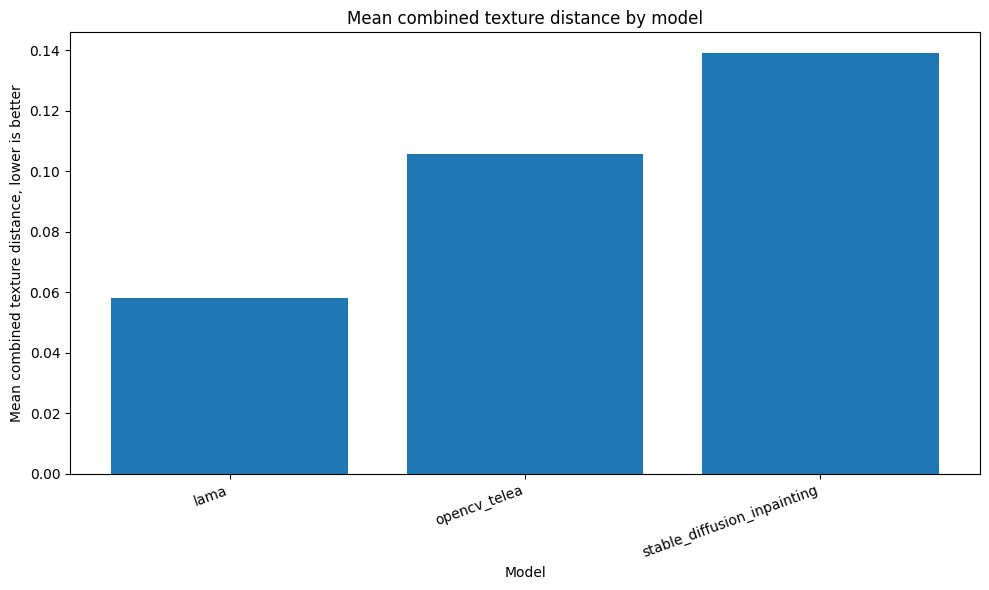

Saved figure: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\figures\texture_metrics\texture_distance_by_model.png


In [29]:
def save_bar_figure(
    df: pd.DataFrame,
    *,
    x_column: str,
    y_column: str,
    title: str,
    xlabel: str,
    ylabel: str,
    output_path: Path,
    rotation: int = 0,
) -> None:
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(df[x_column].astype(str), df[y_column])

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if rotation:
        plt.setp(ax.get_xticklabels(), rotation=rotation, ha="right")

    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()

    print("Saved figure:", output_path)


save_bar_figure(
    texture_summary_by_model_df,
    x_column="model",
    y_column="mean_combined_texture_distance",
    title="Mean combined texture distance by model",
    xlabel="Model",
    ylabel="Mean combined texture distance, lower is better",
    output_path=texture_figure_paths["texture_distance_by_model"],
    rotation=20,
)

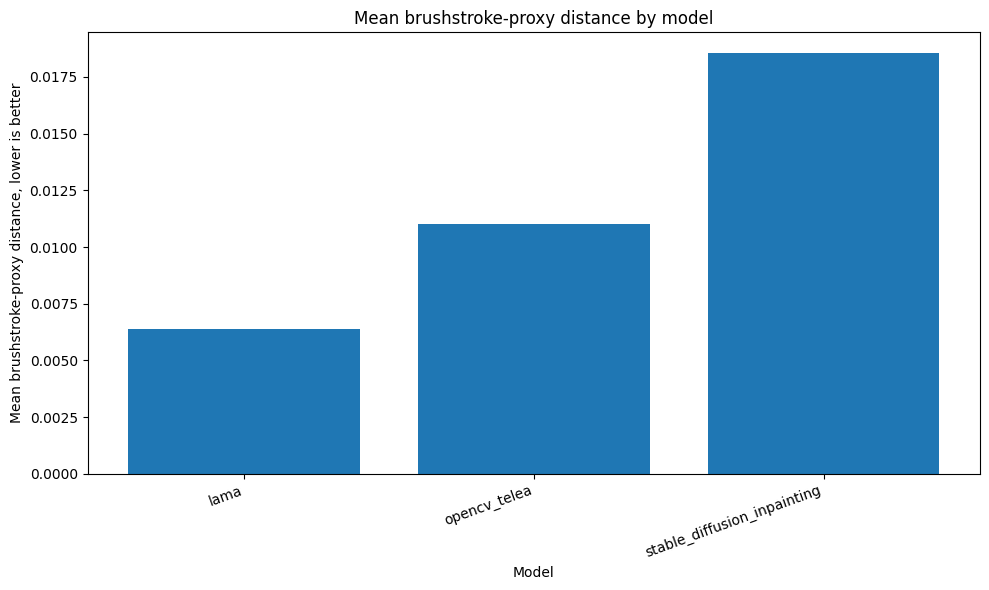

Saved figure: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\figures\texture_metrics\brushstroke_proxy_distance_by_model.png


In [30]:
save_bar_figure(
    brushstroke_proxy_summary_by_model_df,
    x_column="model",
    y_column="mean_brushstroke_proxy_distance",
    title="Mean brushstroke-proxy distance by model",
    xlabel="Model",
    ylabel="Mean brushstroke-proxy distance, lower is better",
    output_path=texture_figure_paths["brushstroke_proxy_distance_by_model"],
    rotation=20,
)

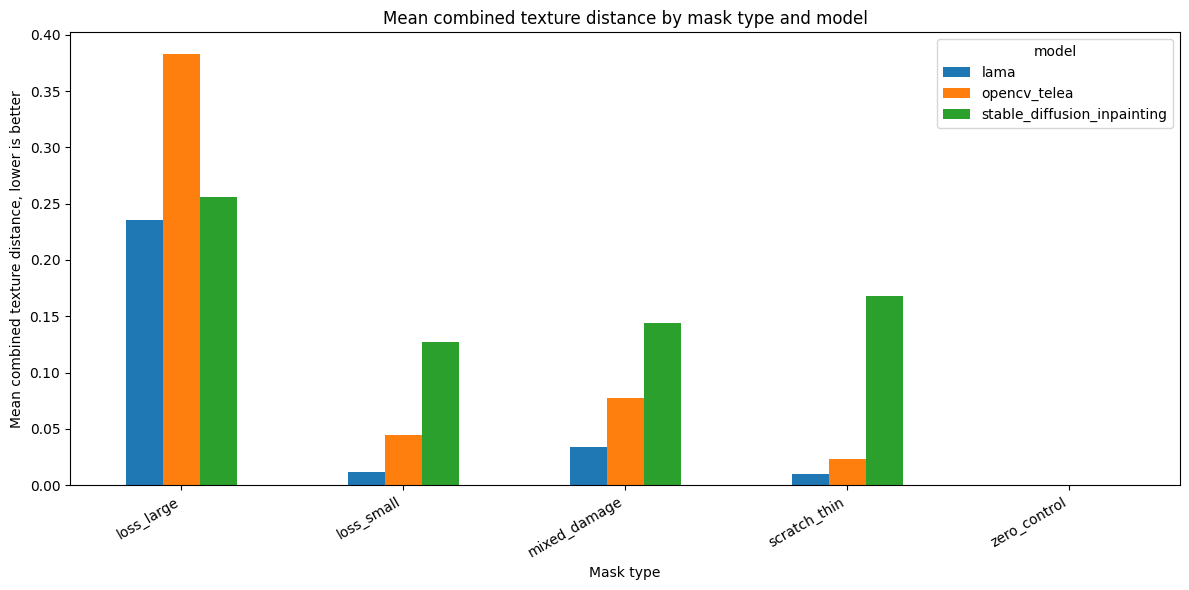

Saved figure: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\figures\texture_metrics\texture_distance_by_mask_type.png


In [31]:
pivot_mask_df = texture_summary_by_mask_type_df.pivot(
    index="mask_type",
    columns="model",
    values="mean_combined_texture_distance",
)

fig, ax = plt.subplots(figsize=(12, 6))

pivot_mask_df.plot(kind="bar", ax=ax)

ax.set_title("Mean combined texture distance by mask type and model")
ax.set_xlabel("Mask type")
ax.set_ylabel("Mean combined texture distance, lower is better")

plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

fig.tight_layout()
fig.savefig(texture_figure_paths["texture_distance_by_mask_type"], dpi=160)
plt.show()

print("Saved figure:", texture_figure_paths["texture_distance_by_mask_type"])

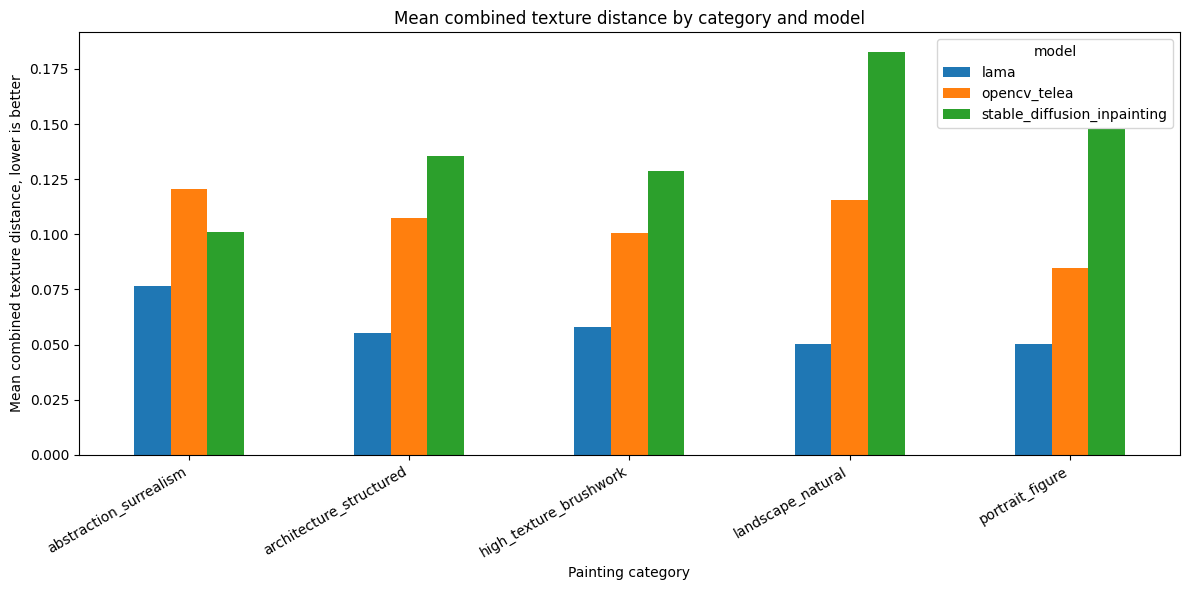

Saved figure: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\figures\texture_metrics\texture_distance_by_category.png


In [32]:
pivot_category_df = texture_summary_by_category_df.pivot(
    index="category",
    columns="model",
    values="mean_combined_texture_distance",
)

fig, ax = plt.subplots(figsize=(12, 6))

pivot_category_df.plot(kind="bar", ax=ax)

ax.set_title("Mean combined texture distance by category and model")
ax.set_xlabel("Painting category")
ax.set_ylabel("Mean combined texture distance, lower is better")

plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

fig.tight_layout()
fig.savefig(texture_figure_paths["texture_distance_by_category"], dpi=160)
plt.show()

print("Saved figure:", texture_figure_paths["texture_distance_by_category"])

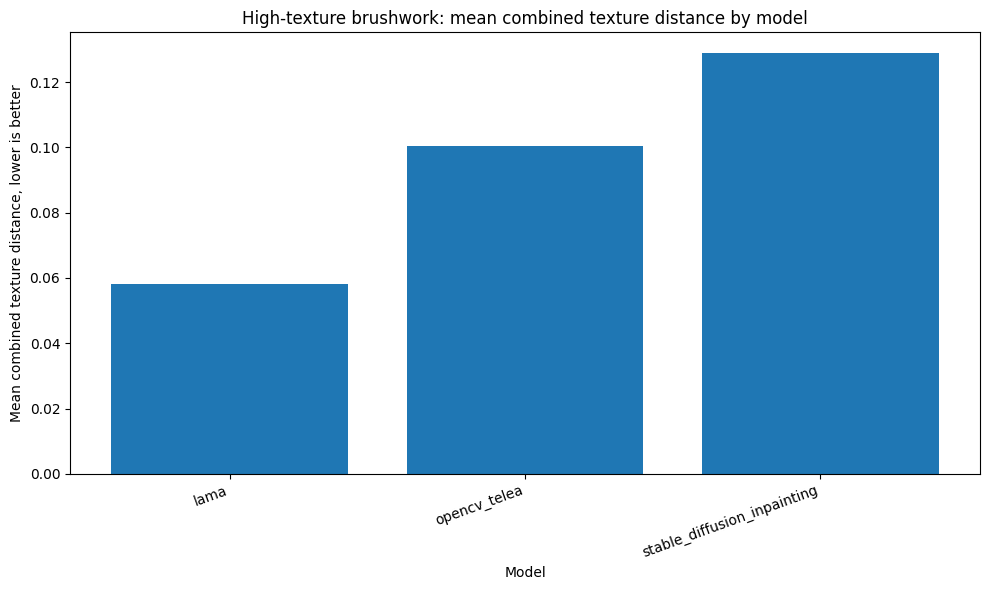

Saved figure: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\figures\texture_metrics\high_texture_brushwork_texture_distance_by_model.png


In [33]:
if not high_texture_summary_df.empty:
    high_texture_by_model_df = (
        high_texture_summary_df
        .groupby("model", as_index=False)
        .agg(
            mean_combined_texture_distance=("mean_combined_texture_distance", "mean"),
            mean_brushstroke_proxy_distance=("mean_brushstroke_proxy_distance", "mean"),
        )
        .sort_values("mean_combined_texture_distance", ascending=True)
    )

    save_bar_figure(
        high_texture_by_model_df,
        x_column="model",
        y_column="mean_combined_texture_distance",
        title="High-texture brushwork: mean combined texture distance by model",
        xlabel="Model",
        ylabel="Mean combined texture distance, lower is better",
        output_path=texture_figure_paths["high_texture_brushwork_texture_distance_by_model"],
        rotation=20,
    )
else:
    print("Skipping high-texture brushwork figure because no high-texture rows were found.")

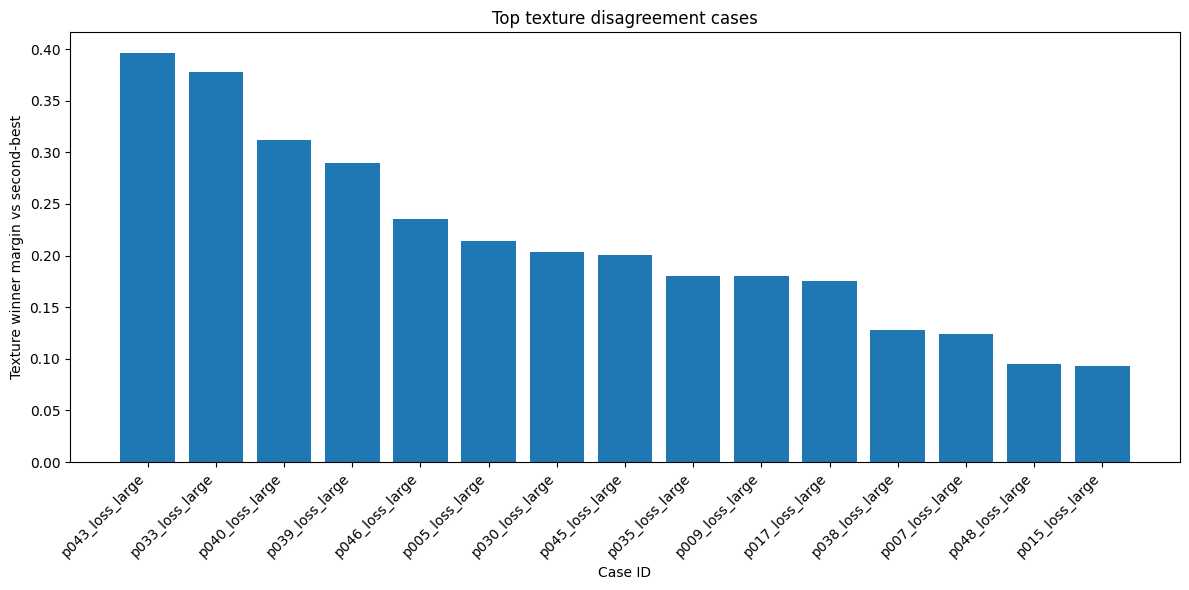

Saved figure: C:\Users\A16904\Documents\One off scripts\painting_restoration_eval-main\outputs\figures\texture_metrics\texture_top_disagreement_cases.png


In [34]:
top_disagreement_df = texture_disagreement_df.copy()

if "texture_disagrees_with_refined_vote" in top_disagreement_df.columns:
    top_disagreement_df = top_disagreement_df[
        top_disagreement_df["texture_disagrees_with_refined_vote"] == True
    ]

top_disagreement_df = top_disagreement_df.sort_values(
    "texture_margin_best_vs_second",
    ascending=False,
).head(15)

if not top_disagreement_df.empty:
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(
        top_disagreement_df["case_id"].astype(str),
        top_disagreement_df["texture_margin_best_vs_second"],
    )

    ax.set_title("Top texture disagreement cases")
    ax.set_xlabel("Case ID")
    ax.set_ylabel("Texture winner margin vs second-best")

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    fig.tight_layout()
    fig.savefig(texture_figure_paths["texture_top_disagreement_cases"], dpi=160)
    plt.show()

    print("Saved figure:", texture_figure_paths["texture_top_disagreement_cases"])
else:
    print("No texture disagreement cases available for plotting.")

In [35]:
texture_status_counts = texture_unified_df["texture_metric_status"].value_counts(dropna=False)

if "ok" not in texture_status_counts.index:
    raise ValueError("No successful texture metric rows found.")

successful_rows = int(texture_status_counts.get("ok", 0))

if successful_rows == 0:
    raise ValueError("Texture metric computation produced zero successful rows.")

expected_models = {
    "opencv_telea",
    "lama",
    "stable_diffusion_inpainting",
}

observed_models = set(texture_unified_df["model"].dropna().unique())

missing_models = expected_models - observed_models

if missing_models:
    raise ValueError(f"Missing texture metric models: {missing_models}")

required_texture_columns = [
    "glcm_texture_distance_mean",
    "gabor_texture_distance_mean",
    "brushstroke_proxy_distance_mean",
    "brushstroke_orientation_histogram_l1_distance",
    "brushstroke_orientation_coherence_abs_diff",
    "texture_distance_combined_norm",
]

missing_texture_columns = [
    column
    for column in required_texture_columns
    if column not in texture_unified_df.columns
]

if missing_texture_columns:
    raise ValueError(f"Missing expected texture/brushstroke columns: {missing_texture_columns}")

if texture_case_winners_nonzero_df.empty:
    raise ValueError("Non-zero texture winner table is empty.")

if texture_case_winners_nonzero_df["mask_type"].eq("zero_control").any():
    raise ValueError("Zero-control cases leaked into non-zero texture winner table.")

required_output_files = list(texture_output_paths.values()) + [
    texture_figure_paths["texture_distance_by_model"],
    texture_figure_paths["texture_distance_by_mask_type"],
    texture_figure_paths["texture_distance_by_category"],
    texture_figure_paths["texture_top_disagreement_cases"],
    texture_figure_paths["brushstroke_proxy_distance_by_model"],
]

if not high_texture_summary_df.empty:
    required_output_files.append(
        texture_figure_paths["high_texture_brushwork_texture_distance_by_model"]
    )

missing_output_files = [
    path
    for path in required_output_files
    if not path.exists()
]

if missing_output_files:
    for path in missing_output_files:
        print("Missing:", path)

    raise FileNotFoundError("Some expected texture/brushstroke outputs are missing.")

print("Texture metric status counts:")
display(texture_status_counts)

print("Observed models:", sorted(observed_models))
print("Successful texture metric rows:", successful_rows)

print("Non-zero texture winner counts:")
display(texture_case_winners_nonzero_df["texture_winner_model"].value_counts())

print("Notebook 31 final validation passed.")

Texture metric status counts:


texture_metric_status
ok    750
Name: count, dtype: int64

Observed models: ['lama', 'opencv_telea', 'stable_diffusion_inpainting']
Successful texture metric rows: 750
Non-zero texture winner counts:


texture_winner_model
lama                           175
stable_diffusion_inpainting     24
opencv_telea                     1
Name: count, dtype: int64

Notebook 31 final validation passed.


## Notebook 31 summary

Texture-aware and brushstroke-proxy metrics were added to the controlled 50-painting evaluation framework.

This notebook computed:

- GLCM texture descriptor differences,
- Gabor response descriptor differences,
- brushstroke-proxy orientation metrics,
- normalized combined texture distance,
- model-level texture summaries,
- mask-type texture summaries,
- category-level texture summaries,
- high-texture brushwork focused summaries,
- non-zero-only texture winner counts,
- texture disagreement cases against the refined overall metric vote.

The brushstroke-proxy metrics do not perform semantic brushstroke recognition. They measure directional local texture structure using gradient magnitude, orientation coherence, edge/detail density, and orientation histogram similarity.

The texture and brushstroke-proxy metrics use the `mask_bbox_crop` region because these descriptors require local spatial structure.

Zero-control cases are retained in the unified texture metric table for completeness, but excluded from non-zero winner and disagreement analysis because zero-control distances can create arbitrary winners.

Documentation updates are handled manually in the project Markdown docs so that this notebook remains focused on metric computation and output validation.

The next notebook should add spatial uncertainty heatmaps for the existing Stable Diffusion multi-seed uncertainty subset.